# Findings

In [2]:
from gravpop import *

import sys
sys.path.append("..")
from src import *

import os
root_folder = os.path.dirname(os.getcwd())

import numpy as np

def calc_min_interval(x, alpha):
    """Internal method to determine the minimum interval of a given width
    Assumes that x is sorted numpy array.
    """

    n = len(x)
    cred_mass = 1.0-alpha

    interval_idx_inc = int(np.floor(cred_mass*n))
    n_intervals = n - interval_idx_inc
    interval_width = x[interval_idx_inc:] - x[:n_intervals]

    if len(interval_width) == 0:
        raise ValueError('Too few elements for interval calculation')

    min_idx = np.argmin(interval_width)
    hdi_min = x[min_idx]
    hdi_max = x[min_idx+interval_idx_inc]
    return hdi_min, hdi_max


def hpd(x, alpha=0.1):
    """Calculate highest posterior density (HPD) of array for given alpha. 
    The HPD is the minimum width Bayesian credible interval (BCI).
    :Arguments:
        x : Numpy array
        An array containing MCMC samples
        alpha : float
        Desired probability of type I error (defaults to 0.05)

    """

    # Make a copy of trace
    x = x.copy()
    # For multivariate node
    if x.ndim > 1:
        # Transpose first, then sort
        tx = np.transpose(x, list(range(x.ndim))[1:]+[0])
        dims = np.shape(tx)
        # Container list for intervals
        intervals = np.resize(0.0, dims[:-1]+(2,))

        for index in make_indices(dims[:-1]):
            try:
                index = tuple(index)
            except TypeError:
                pass

            # Sort trace
            sx = np.sort(tx[index])
            # Append to list
            intervals[index] = calc_min_interval(sx, alpha)
        # Transpose back before returning
        return np.array(intervals)
    else:
        # Sort univariate node
        sx = np.sort(x)
        return np.array(calc_min_interval(sx, alpha))
    
from truncatedgaussianmixtures import *
    
from tqdm.notebook import tqdm, trange
def get_ranges(x, level=90):
    #med, low, hi = np.median(x), np.percentile(x, (100-level)/2),np.percentile(x, 100 - (100-level)/2)
    low, hi = hpd(x, alpha=(100-level)*0.01)
    return low, np.median(x), hi

def print_ranges(low, med, hi, level=90):
    return f"{np.round(med, 2)}" + r"^{+" + f"{np.round(hi-med, 2)}" + r"}_{-" + f"{np.round(med-low, 2)}" + r"}"

def get_bayes_factor(samples, variables, limit, a, b, prior_value=1, 
                     quantile_level=0.9, trials=100, bandwidth_scale=1):
    bfs = np.zeros(trials);
    for i in trange(trials):
        fit = fit_kde(samples[variables].sample(len(samples), replace=True),a,b, bandwidth_scale=bandwidth_scale);
        bfs[i] = fit.pdf(np.asarray(limit))/prior_value
        
    med, low, hi = np.median(bfs), np.percentile(bfs, 5),np.percentile(bfs, 95)
    #low, hi = hpd(1/bfs, alpha=(100-level)*0.01)
    return (low, med, hi), bfs

Detected Jupyter notebook. Loading juliacall extension. Set `PYSR_AUTOLOAD_EXTENSIONS=no` to disable.


#### Grab samples

In [2]:
posterior_samples = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-Correlated-more_samps.csv");
posterior_samples_no_190517 = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-Correlated-more_samps-no-190517.csv");


posterior_samples['rho_chi_1_true'] = get_correlations(mu1=posterior_samples['mu_chi_1_at_0'], 
                                                       sig1=posterior_samples['sigma_chi_1_at_0'], 
                                                       mu2=posterior_samples['mu_chi_2_at_0'], 
                                                       sig2=posterior_samples['sigma_chi_2_at_0'], 
                                                       rho=posterior_samples['rho_chi_1'])

posterior_samples['rho_chi_2_true'] = get_correlations(mu1=posterior_samples['mu_chi_1'], 
                                                       sig1=posterior_samples['sigma_chi_1'], 
                                                       mu2=posterior_samples['mu_chi_2'], 
                                                       sig2=posterior_samples['sigma_chi_2'], 
                                                       rho=posterior_samples['rho_chi_2'])

posterior_samples_no_190517['rho_chi_1_true'] = get_correlations(mu1=posterior_samples_no_190517['mu_chi_1_at_0'], 
                                                       sig1=posterior_samples_no_190517['sigma_chi_1_at_0'], 
                                                       mu2=posterior_samples_no_190517['mu_chi_2_at_0'], 
                                                       sig2=posterior_samples_no_190517['sigma_chi_2_at_0'], 
                                                       rho=posterior_samples_no_190517['rho_chi_1'])

posterior_samples_no_190517['rho_chi_2_true'] = get_correlations(mu1=posterior_samples_no_190517['mu_chi_1'], 
                                                       sig1=posterior_samples_no_190517['sigma_chi_1'], 
                                                       mu2=posterior_samples_no_190517['mu_chi_2'], 
                                                       sig2=posterior_samples_no_190517['sigma_chi_2'], 
                                                       rho=posterior_samples_no_190517['rho_chi_2'])

posterior_one_component_samples = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/Correlated/Independent_Spins_Correlated_TGMM_new_more_samples.csv");

posterior_one_component_samples['rho_chi_true'] = get_correlations(mu1=posterior_one_component_samples['mu_chi_1'], 
                                                       sig1=posterior_one_component_samples['sigma_chi_1'], 
                                                       mu2=posterior_one_component_samples['mu_chi_2'], 
                                                       sig2=posterior_one_component_samples['sigma_chi_2'], 
                                                       rho=posterior_one_component_samples['rho_chi'])

Nsamps = len(posterior_samples)
prior_samples = {k:np.random.rand(Nsamps) for k in posterior_samples.keys()};
prior_samples['rho_chi_1'] = 2*np.random.rand(Nsamps) - 1
prior_samples['rho_chi_2'] = 2*np.random.rand(Nsamps) - 1

prior_samples['rho_chi_1_true'] = get_correlations(mu1=prior_samples['mu_chi_1_at_0'], 
                                                       sig1=prior_samples['sigma_chi_1_at_0'], 
                                                       mu2=prior_samples['mu_chi_2_at_0'], 
                                                       sig2=prior_samples['sigma_chi_2_at_0'], 
                                                       rho=prior_samples['rho_chi_1'])

prior_samples['rho_chi_2_true'] = get_correlations(mu1=prior_samples['mu_chi_1'], 
                                                       sig1=prior_samples['sigma_chi_1'], 
                                                       mu2=prior_samples['mu_chi_2'], 
                                                       sig2=prior_samples['sigma_chi_2'], 
                                                       rho=prior_samples['rho_chi_2'])

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


# The Model

We try to test whether there exists a subpopulation of black holes differentiated by their primary and secondary spin magnitudes. To that end, we model our spins as coming from two independent truncated bivariate gaussians:

$$
\vec{\chi} \sim \eta \mathcal{N}_{[0,1]}(\vec{\mu}_a, \Sigma_a) + (1-\eta)  \mathcal{N}_{[0,1]}(\vec{\mu}_b, \Sigma_b)
$$

where each of the gaussians is completely general:

$$
\begin{align}
\vec{\mu} &= [\mu_1, \mu_2] \,, & 
\Sigma & = \begin{pmatrix}
\sigma_1^2 & \rho \sigma_1 \sigma_2 \\
 \rho \sigma_1 \sigma_2 &  \sigma_2^2
\end{pmatrix} \,,
\end{align}
$$

To break the degenracy, we set the prior range on the fraction $\eta$,  as $\eta \in (0.5, 1)$. This makes sure the dominant component in the first component.  

# Findings

We find hints that the detected BBHs come from two distinct sub-populations (with a Bayes factor in favor of the existence of this structure of $\mathcal{B} \approx 2.8$):
- A sub-population of BBHs that are more rapidly spinning ($\chi_1 \approx 0.6 , \chi_2 \approx 0.6$), making up around $\approx 20^{+24}_{-16}\%$ of BBHs.
  - The exact spread and location of this secondary component is not very well localized, but most definitely tends to have larger spins than the first component.
  - These black holes tend to:
    - Be more massive.
    - Have more spin tilt alignment.
    - No evidence for a correlation between the primary and secondary spin of this component.

- The remaining BBHs have properties very similar to those inferred by the LVK and others in the case of a one-component model:
  - Most of the primary BHs have spins of around $0.2$.
  - The secondary isn't well constrained but is more likely to be close to $0$.
  - Some evidence of an anti-correlation ($\rho_{true} \approx -0.2^{+0.6}_{-0.4}$) between the primary and secondary spin for this component. Where $\rho_{true} = \text{Cov}[\chi_1, \chi_2]/ \sqrt{\text{Var}[\chi_1]\text{Var}[\chi_2]}$. (Rename $\rho_{true}$.)
    - Important to note: this is the true correlation for a truncated two-dimensional Gaussian, as opposed to the $\rho$ that appears as a parameter of the truncated normal. These two definitions are equal for a multivariate normal, but this changes after truncation within some bounds.
  - In a one-component analysis, an anti-correlation of $\rho \approx -0.1$ still appears. 
    - This is significant since a uniform prior on the correlation parameter of the truncated Gaussian imposes a strict prior on the true correlation around $\rho \approx 0$.
  - The methodology allows for continuity into the $\sigma \to 0$ regime without additional parameter estimation runs.
    - It is possible that this dominant population is consistent with BBHs where primaries have spins of exactly $0.2$ (with no spread) and secondaries are non-spinning.
    - A spread around those values is also possible. For the full corner plot, refer to Fig. blah.

- This subpopulation is driven by the high (and well-constrained) spins of GW190517.
  - Without this event, the data no longer prefers this subpopulation, with the Bayes factor against it being $\mathcal{B} \approx 1.6$.
  - Note: this does not imply that GW190517 is the only event in this component. The component likely contains around 13 events.




#### Define the spin magnitude models

In [3]:
### Set up the spin magnitude models
var_names = ['chi_1', 'chi_2'];
a = [0,0]; b=[1,1];
the_spin_magnitude_model_2D = FixedParameters(Mixture2D(
                                                TruncatedGaussian2DAnalytic(var_names=var_names, 
                                                                            hyper_var_names=['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1'], 
                                                                            a=a, b=b),
                                                TruncatedGaussian2DAnalytic(var_names=var_names, 
                                                                            hyper_var_names=['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2'], 
                                                                            a=a, b=b),
                                                'eta_spin'
                                            ), {})

the_spin_magnitude_model_2D_switched = FixedParameters(Mixture2D(
                                                TruncatedGaussian2DAnalytic(var_names=var_names, 
                                                                            hyper_var_names=['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2'], 
                                                                            a=a, b=b),
                                                TruncatedGaussian2DAnalytic(var_names=var_names, 
                                                                            hyper_var_names=['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1'], 
                                                                            a=a, b=b),
                                                'eta_spin'
                                            ), {})

# Posterior Predictives in 2D

## Posterior predictives hint at a higher spinning component

9999


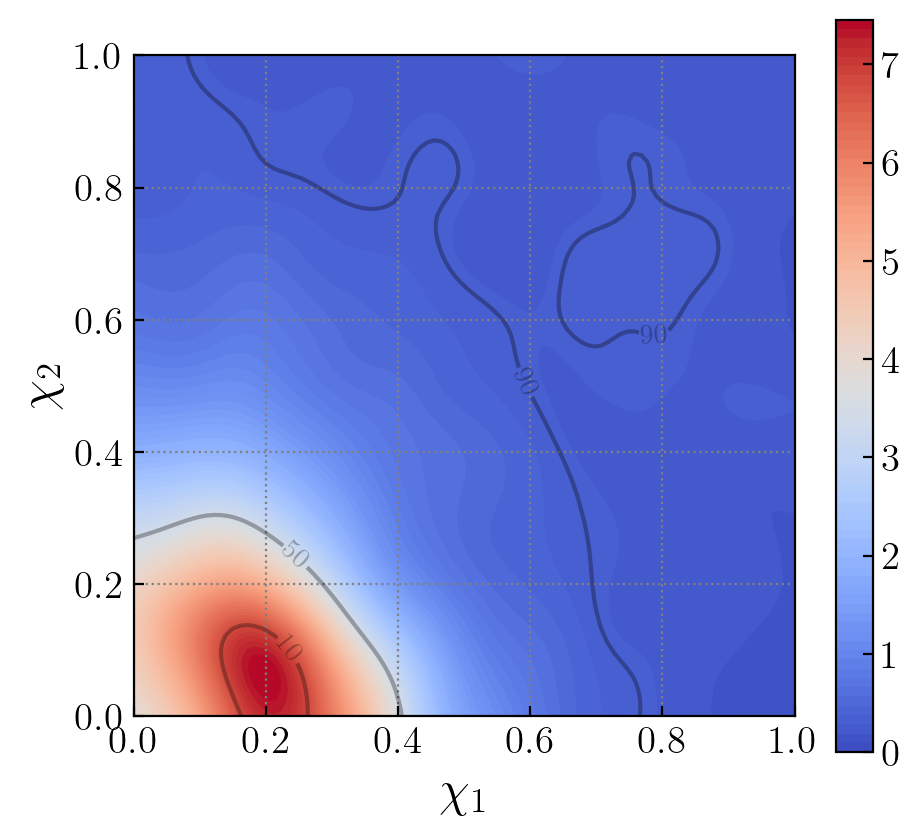

In [4]:
fig = SpinMagintudePlot(makedict(posterior_samples[posterior_samples['eta_spin'] > posterior_samples['eta_spin'].quantile(0.0)]), the_spin_magnitude_model_2D).spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()
plt.show()
#fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/PPD.pdf",bbox_inches='tight',dpi=200)

## Just the dominant component

10000


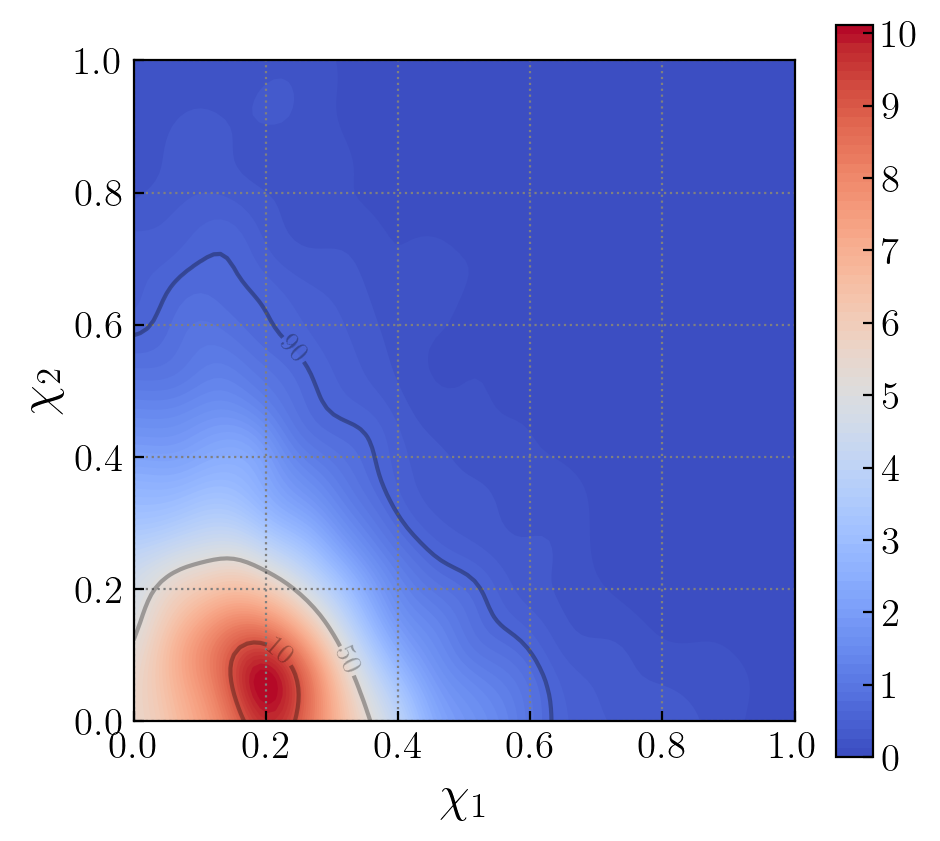

In [65]:
fig = SpinMagintudePlot(makedict(posterior_samples), the_spin_magnitude_model_2D.models[0]).spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()
fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/PPD_dominant.pdf",bbox_inches='tight',dpi=200);

## Just the sub-dominant component

10000


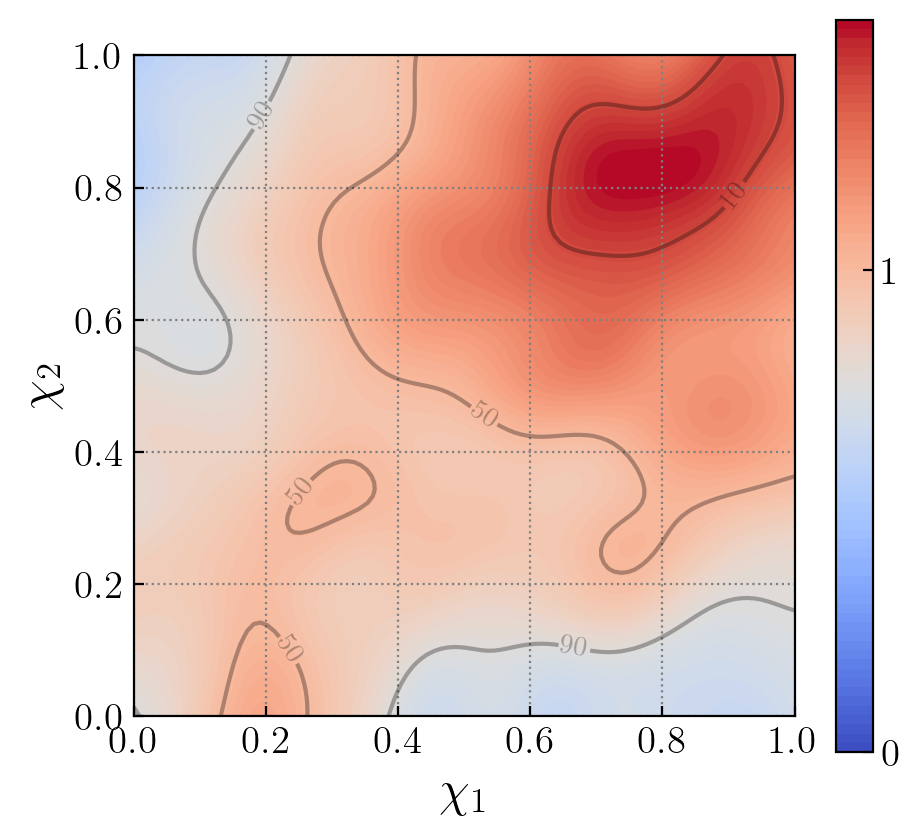

In [67]:
bkde = SpinMagintudePlot(makedict(posterior_samples), the_spin_magnitude_model_2D.models[1], n_samples=None)
fig = bkde.spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()
fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/PPD_sub_dominant.pdf",bbox_inches='tight',dpi=200);

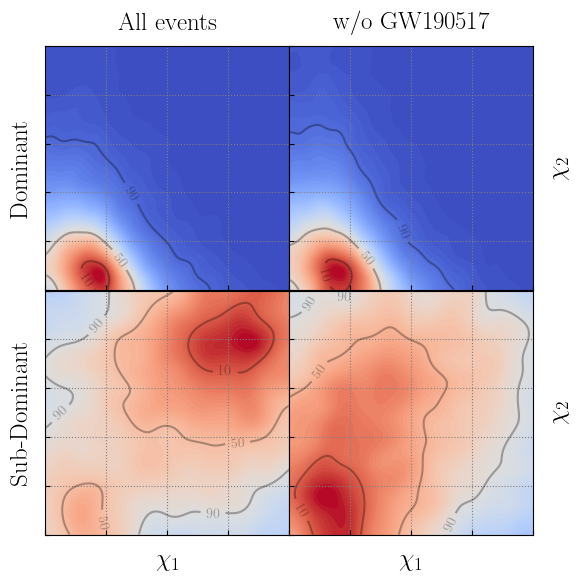

In [728]:
import matplotlib.pyplot as plt

# Create 2x2 subplots with shared axes
fig, axes = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0}, figsize=(6, 6))

# Set spacing between plots to zero
plt.subplots_adjust(wspace=0, hspace=0)

# Remove tick labels for the required subplots
axes[0, 0].set_xticklabels([])
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])
axes[1, 1].set_yticklabels([])

# Label the quadrants
axes[0, 0].text(0.5, 1.05, 'All events', ha='center', va='bottom', transform=axes[0, 0].transAxes, fontsize=18)
axes[0, 1].text(0.5, 1.05, 'w/o GW190517', ha='center', va='bottom', transform=axes[0, 1].transAxes, fontsize=18)
axes[0, 0].text(-0.1, 0.5, 'Dominant', ha='center', va='center', rotation=90, transform=axes[0, 0].transAxes, fontsize=18)
axes[1, 0].text(-0.1, 0.5, 'Sub-Dominant', ha='center', va='center', rotation=90, transform=axes[1, 0].transAxes, fontsize=18)
axes[0, 1].text(0.1+1, 0.5, r'$\chi_2$', ha='center', va='center', rotation=90, transform=axes[0, 1].transAxes, fontsize=18)
axes[1, 1].text(0.1+1, 0.5, r'$\chi_2$', ha='center', va='center', rotation=90, transform=axes[1, 1].transAxes, fontsize=18)
axes[1, 0].text(0.5, -0.1, r'$\chi_1$', ha='center', va='center', rotation=0, transform=axes[1, 0].transAxes, fontsize=18)
axes[1, 1].text(0.5, -0.1, r'$\chi_1$', ha='center', va='center', rotation=0, transform=axes[1, 1].transAxes, fontsize=18)


from truncnormkde import BoundedKDEPlot
quantiles = [0.9, 0.5, 0.1]
oversample = 50000 // len(posterior_samples)

dfsamps = the_spin_magnitude_model_2D.models[0].sample(posterior_samples, oversample=oversample)
bkde = BoundedKDEPlot(dfsamps, latex_labels={'chi_1': r'$\chi_1$', 'chi_2': r'$\chi_2$'})
computed_values, X_grid, x_2d, y_2d = bkde.compute_values_on_grid(bkde.X)
cont, ax, cmax = bkde.plot_on_axis(computed_values, X_grid, x_2d, y_2d, ax=axes[0,0], quantiles=quantiles)
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("");

dfsamps = the_spin_magnitude_model_2D.models[0].sample(posterior_samples_no_190517, oversample=oversample)
bkde = BoundedKDEPlot(dfsamps, latex_labels={'chi_1': r'$\chi_1$', 'chi_2': r'$\chi_2$'})
computed_values, X_grid, x_2d, y_2d = bkde.compute_values_on_grid(bkde.X)
cont, ax, cmax = bkde.plot_on_axis(computed_values, X_grid, x_2d, y_2d, ax=axes[0,1], quantiles=quantiles)
axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("");

dfsamps = the_spin_magnitude_model_2D.models[1].sample(posterior_samples, oversample=oversample)
bkde = BoundedKDEPlot(dfsamps, latex_labels={'chi_1': r'$\chi_1$', 'chi_2': r'$\chi_2$'})
computed_values, X_grid, x_2d, y_2d = bkde.compute_values_on_grid(bkde.X)
cont, ax, cmax = bkde.plot_on_axis(computed_values, X_grid, x_2d, y_2d, ax=axes[1,0], quantiles=quantiles)
axes[1, 0].set_xlabel(""); axes[1, 0].set_ylabel("");

dfsamps = the_spin_magnitude_model_2D.models[1].sample(posterior_samples_no_190517, oversample=oversample)
bkde = BoundedKDEPlot(dfsamps, latex_labels={'chi_1': r'$\chi_1$', 'chi_2': r'$\chi_2$'})
computed_values, X_grid, x_2d, y_2d = bkde.compute_values_on_grid(bkde.X)
cont, ax, cmax = bkde.plot_on_axis(computed_values, X_grid, x_2d, y_2d, ax=axes[1,1], quantiles=quantiles)
axes[1, 1].set_xlabel(""); 
axes[1, 1].set_ylabel("");
#axes[0,0].annotate("0.25", (0.25-0.05,0.85)) Add xticks
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
plt.tight_layout()
# Show the plot
plt.show()

fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/PPD_both_dom_subdom.pdf", bbox_inches='tight',dpi=200)

## The existence of this component is dependent on GW190517

In [105]:
## NOTE: This will install julia within the conda environment. 
## It may take up to 10-20 min the first time this package is imported
from truncatedgaussianmixtures import *

#fit = fit_gmm(posterior_samples[['eta_spin']], 10, [0], [1], cov="diag", tol=1e-8, MAX_REPS=600);
fit = fit_kde(posterior_samples[['eta_spin']], [0], [1], bandwidth_scale=0.6);
fit2 = fit_kde(posterior_samples_no_190517[['eta_spin']], [0], [1], bandwidth_scale=0.6);

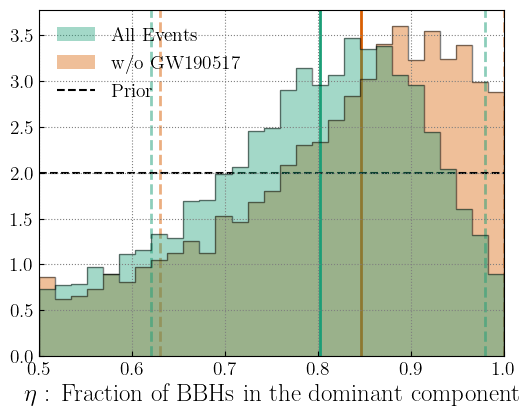

In [705]:
#plt.hist(fit.sample(len(posterior_samples)), alpha=0.5, label="Fit", bins=np.linspace(0.5,1,30), density=True)
fig_hist, _ = plt.subplots(1);
plt.hist(posterior_samples['eta_spin'], alpha=0.4, bins=np.linspace(0.5,1,30), density=True, color=default_pallete[0], label="All Events")
plt.hist(posterior_samples['eta_spin'], alpha=0.5, bins=np.linspace(0.5,1,30), density=True, histtype='step', edgecolor='black', zorder=2)
plt.hist(posterior_samples_no_190517['eta_spin'], alpha=0.4,
         bins=np.linspace(0.5,1,30), density=True, color=default_pallete[1], label="w/o GW190517", zorder=0)
plt.hist(posterior_samples_no_190517['eta_spin'], alpha=0.5, bins=np.linspace(0.5,1,30), density=True, histtype='step', edgecolor='black', zorder=2)
etas = np.linspace(0.5,1,100)

plt.axvline(x_interval['median'], color=default_pallete[0], zorder=0, linewidth=2)
plt.axvline(x_interval['median'] + x_interval['plus'], color=default_pallete[0], zorder=0, linestyle="dashed", linewidth=2, alpha=0.5)
plt.axvline(x_interval['median'] - x_interval['minus'] , color=default_pallete[0], zorder=0, linestyle="dashed", linewidth=2, alpha=0.5)

plt.axvline(x_interval_no_GW190517['median'], color=default_pallete[1], zorder=0, linewidth=2)
plt.axvline(x_interval_no_GW190517['median'] + x_interval_no_GW190517['plus'], color=default_pallete[1], zorder=0, linestyle="dashed", linewidth=2, alpha=0.5)
plt.axvline(x_interval_no_GW190517['median'] - x_interval_no_GW190517['minus'] , color=default_pallete[1], zorder=0, linestyle="dashed", linewidth=2, alpha=0.5)

#plt.plot(etas, np.array(fit.pdf(etas)), color=default_pallete[0], label="All Events")
#plt.plot(etas, np.array(fit2.pdf(etas)), color=default_pallete[1], label="w/o GW190517")
plt.plot(etas, np.ones_like(etas)*2, color="black", linestyle="dashed", label="Prior", zorder=0)
plt.xlim(0.5,1)
plt.xlabel(r"$\eta$ : Fraction of BBHs in the dominant component")
thelegend = plt.legend()
thelegend.get_frame().set_facecolor((1,1,1,1))
thelegend.get_frame().set_edgecolor('none')
plt.show()
fig_hist.savefig(f"{root_folder}/figures/TwoComponent/Correlated/fraction_histogram.pdf",bbox_inches='tight',dpi=200)

In [854]:
print(f"Dominant fraction is {print_ranges(*get_ranges(posterior_samples['eta_spin'], level=90))}")
print(f"Sub-dominant fraction is {print_ranges(*get_ranges(posterior_samples['eta_spin'], level=90))}")
print("")
print(f"Dominant fraction at 95% is {print_ranges(*get_ranges(posterior_samples['eta_spin'], level=95))}")
print(f"Sub-dominant fraction at 95% is {print_ranges(*get_ranges(posterior_samples['eta_spin'], level=95))}")
print("")
print(f"Dominant fraction without GW190517 is {print_ranges(*get_ranges(posterior_samples_no_190517['eta_spin']))}")
print(f"Sub-dominant fraction without GW190517 is {print_ranges(*get_ranges(posterior_samples_no_190517['eta_spin']))}")

Dominant fraction is 0.8^{+0.17}_{-0.21}
Sub-dominant fraction is 0.8^{+0.17}_{-0.21}

Dominant fraction at 95% is 0.8^{+0.19}_{-0.25}
Sub-dominant fraction at 95% is 0.8^{+0.19}_{-0.25}

Dominant fraction without GW190517 is 0.85^{+0.15}_{-0.22}
Sub-dominant fraction without GW190517 is 0.85^{+0.15}_{-0.22}


In [783]:
lims, bfs = get_bayes_factor(posterior_samples, ['eta_spin'], trials=200,
                             limit=[1], a=[0.5], b=[1], prior_value=2, bandwidth_scale=0.6); # using scale 0.6 looks closer to histogram

print("Bayes factor in favor of this sub-population existing is ", print_ranges(*get_ranges(1/bfs, level=90)))

  0%|          | 0/200 [00:00<?, ?it/s]

Bayes factor in favor of this sub-population existing is  2.1^{+0.28}_{-0.32}


In [849]:
lims, bfs = get_bayes_factor(posterior_samples_no_190517, ['eta_spin'], trials=200,
                             limit=[1], a=[0.5], b=[1], prior_value=2, bandwidth_scale=0.6); # using scale 0.6 looks closer to histogram

print("Bayes factor against this sub-population existing is ", print_ranges(*get_ranges(bfs, level=90)))

  0%|          | 0/200 [00:00<?, ?it/s]

Bayes factor against this sub-population existing is  1.39^{+0.11}_{-0.1}


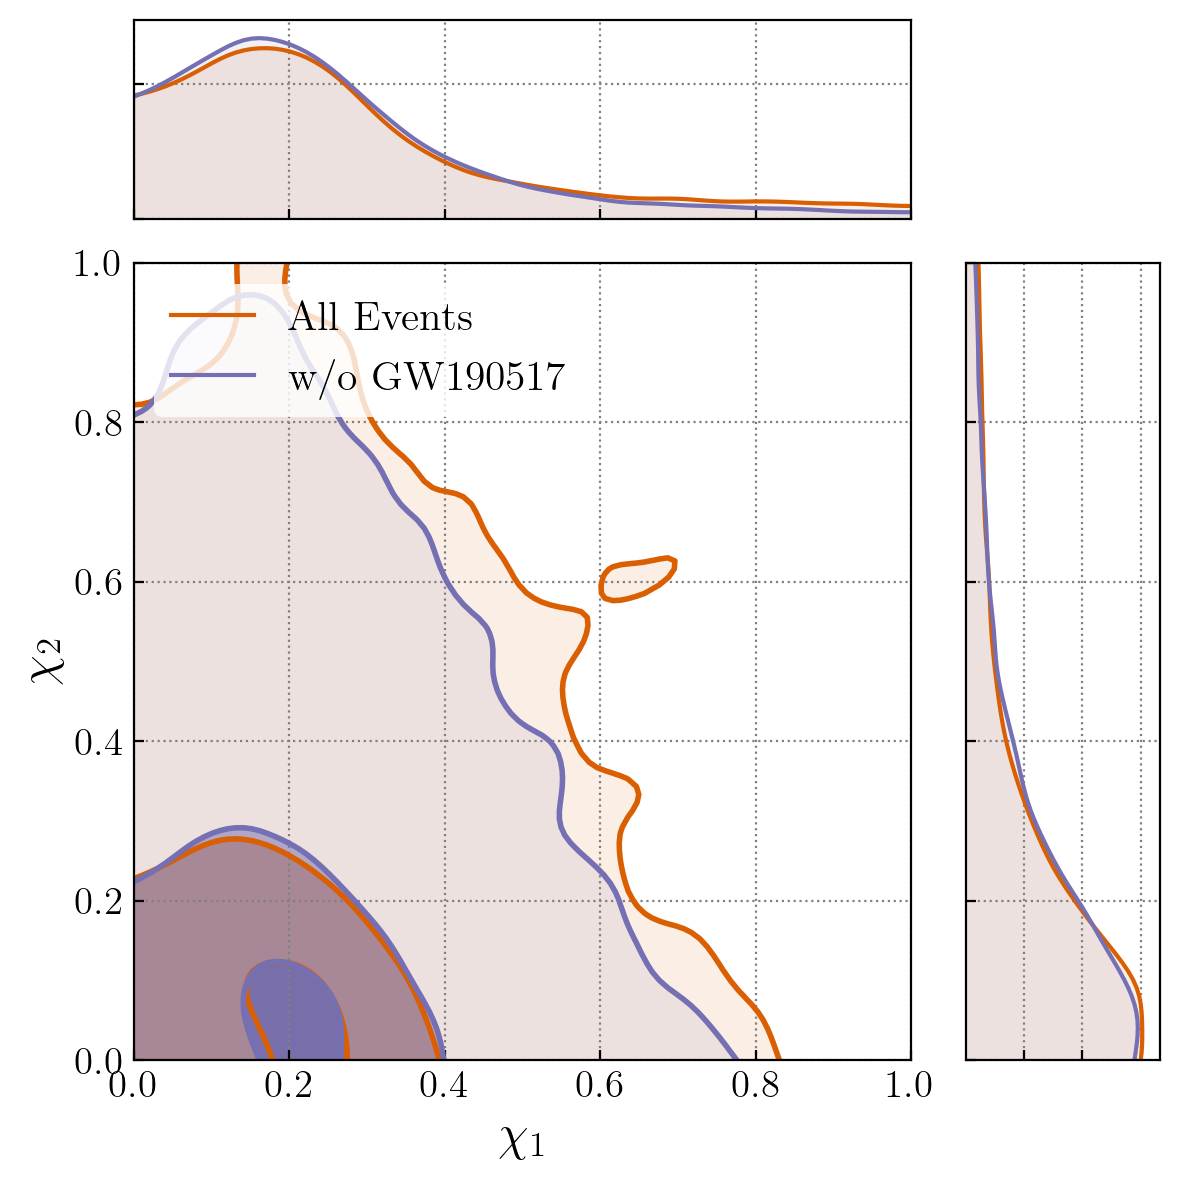

In [857]:
from truncnormkde import *
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples_no_190517[cond])
dfsamps2 = the_spin_magnitude_model_2D.sample(posterior_samples_no_190517[cond], oversample=oversample)

fig = make_2D_comparison(dfsamps, dfsamps2, 
                         quantiles=[0.9,0.5,0.1],
                         legend_location='upper left', 
                         model_labels = ['All Events', 'w/o GW190517'], 
                         legend_face_color=(1,1,1)
                        )

fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/PPD_compared_to_190517_2.pdf", bbox_inches='tight',dpi=200)

## Zero Spin bayes factor

In [767]:
lims, bfs = get_bayes_factor(posterior_samples,
                 ['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0'], 
                [0,0,0,0], [0,0,0,0], [1,1,1,1],trials=500);

lims2, bfs2 = get_bayes_factor(posterior_samples,
                ['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2'], 
                [0,0,0,0], [0,0,0,0], [1,1,1,1],trials=500);

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [768]:
print(f"Bayes factor against a dominant zero spin component is {print_ranges(*get_ranges(1/bfs), level=90)}")
print(f"Bayes factor against a sub-dominant zero spin component is {print_ranges(*get_ranges(1/bfs2), level=90)}")

Bayes factor against a dominant zero spin component is 8.09^{+44.5}_{-6.01}
Bayes factor against a sub-dominant zero spin component is 6.03^{+3.25}_{-2.23}


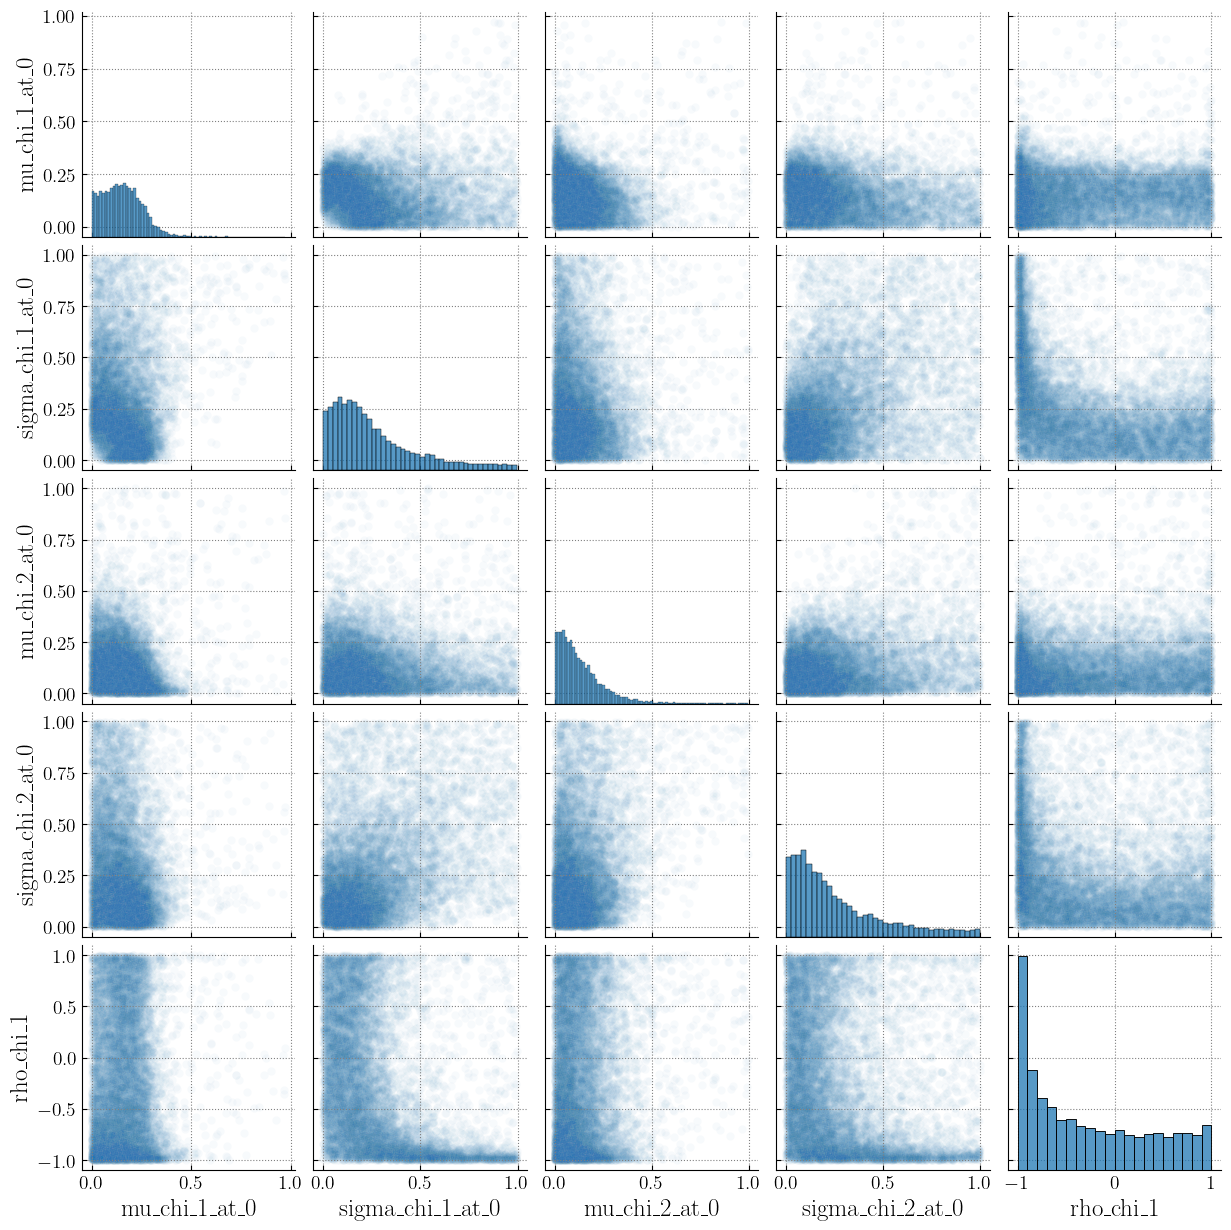

In [460]:
sns.pairplot(
    posterior_samples[['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1']],
    plot_kws=dict(alpha=0.03)
)
plt.show()

## Correlation Bayes Factors

In [769]:
lims, bfs = get_bayes_factor(posterior_samples, 
                 ['rho_chi_1'], 
                [0], [-1], [1], prior_value=1/2);

print("Bayes factor in favor of some correlation structure for the dominant sub-population is ", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor in favor of some correlation structure for the dominant sub-population is  1.43^{+0.05}_{-0.07}


In [770]:
lims, bfs = get_bayes_factor(posterior_samples, 
                 ['rho_chi_1', 'rho_chi_2'], 
                [0,0], [-1,-1], [1,1], prior_value=1/4);

print("Bayes factor in favor of some correlation structure for the both the dominant and sub-dominant sub-population is ", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor in favor of some correlation structure for the both the dominant and sub-dominant sub-population is  1.33^{+0.11}_{-0.15}


In [779]:
posterior_samples_2 = posterior_samples.copy()

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_one_component_samples)
    fit_all_one_correlation = fit_kde(posterior_one_component_samples[['rho_chi_true']].sample(Ns, replace=True), 
              [-1], [1]);

    fit_all_one_correlation_prior = fit_kde(pd.DataFrame(prior_samples)[['rho_chi_1_true']].sample(Ns, replace=True), 
                  [-1], [1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior


#med, low, hi = np.median(1/bfs), np.percentile(1/bfs, 5),np.percentile(1/bfs, 95)
#print(print_ranges(low, med, hi))

print("We are comparing a model with only one population $\\vec{\chi} \\sim N_{[0,1]}(\\vec{\\mu}, \\Sigma)$")
print("Bayes factor for all BBHs having some correlation(using pearson correlation coefficient) ", print_ranges(*get_ranges(1/bfs), level=90))


  0%|          | 0/100 [00:00<?, ?it/s]

We are comparing a model with only one population $\vec{\chi} \sim N_{[0,1]}(\vec{\mu}, \Sigma)$
Bayes factor for all BBHs having some correlation(using pearson correlation coefficient)  2.1^{+0.1}_{-0.06}


In [780]:
posterior_samples_2 = posterior_samples.copy()

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_samples_2)
    fit_all_one_correlation = fit_kde(posterior_samples[['rho_chi_1_true']].sample(Ns, replace=True), 
              [-1], [1]);

    fit_all_one_correlation_prior = fit_kde(pd.DataFrame(prior_samples)[['rho_chi_1_true']].sample(Ns, replace=True), 
                  [-1], [1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior

print("Bayes factor for the dominant BBHs having some correlation(using pearson correlation coefficient)", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for the dominant BBHs having some correlation(using pearson correlation coefficient) 2.57^{+0.1}_{-0.1}


In [781]:
posterior_samples_2 = posterior_samples.copy()

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_samples_2)
    fit_all_one_correlation = fit_kde(posterior_samples[['rho_chi_2_true']].sample(Ns, replace=True), 
              [-1], [1]);

    fit_all_one_correlation_prior = fit_kde(pd.DataFrame(prior_samples)[['rho_chi_1_true']].sample(Ns, replace=True), 
                  [-1], [1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior

print("Bayes factor for the sub-dominant BBHs having some correlation(using pearson correlation coefficient)", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for the sub-dominant BBHs having some correlation(using pearson correlation coefficient) 0.92^{+0.03}_{-0.03}


In [782]:
posterior_samples_2 = posterior_samples.copy()

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_samples_2)
    fit_all_one_correlation = fit_kde(posterior_samples_2[['rho_chi_1_true', 'rho_chi_2_true']].sample(Ns, replace=True), 
              [-1,-1], [1,1]);

    fit_all_one_correlation_prior = fit_kde(pd.DataFrame(prior_samples)[['rho_chi_1_true', 'rho_chi_2_true']].sample(Ns, replace=True), 
                  [-1,-1], [1,1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0,0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0,0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior

print("Bayes factor for both the sub-dominant and dominant BBHs having some correlation(using pearson correlation coefficient)", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for both the sub-dominant and dominant BBHs having some correlation(using pearson correlation coefficient) 2.37^{+0.21}_{-0.19}


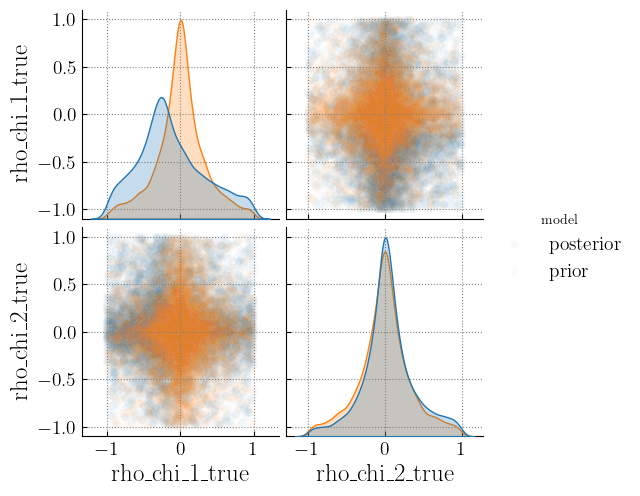

In [79]:
def combine_dfs(dfs, models):
    newdfs = [];
    N = min(len(df) for df in dfs)
    for df,model in zip(dfs, models):
        newdf = df.copy().sample(N);
        newdf['model'] = model
        newdfs.append(newdf)
    return pd.concat(newdfs)
sns.pairplot(combine_dfs(
    [posterior_samples_2[['rho_chi_1_true', 'rho_chi_2_true']], pd.DataFrame(prior_samples)[['rho_chi_1_true', 'rho_chi_2_true']]],
    ['posterior', 'prior']), plot_kws={'alpha':0.03}, hue='model')

## Identical Distributions bayes factor

In [ ]:
posterior_two_component_samples_uncorr = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-more_samps.csv");

posterior_samples_2 = posterior_two_component_samples_uncorr.copy()
posterior_samples_2['d_mu_chi_at_0'] = posterior_samples_2['mu_chi_1_at_0'] - posterior_samples_2['mu_chi_2_at_0']
posterior_samples_2['d_sigma_chi_at_0'] = posterior_samples_2['sigma_chi_1_at_0'] - posterior_samples_2['sigma_chi_2_at_0']
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['mu_chi_1_at_0', 'mu_chi_2_at_0', 'd_sigma_chi_at_0'], 
                [0,0,0], [0,0,-1], [1,1,1], prior_value=1, trials=500);

print("Bayes factor in favor of slow spinning dominant component is ", print_ranges(*get_ranges(bfs), level=90))

In [810]:
posterior_two_component_samples_uncorr = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-more_samps.csv");

posterior_samples_2 = posterior_two_component_samples_uncorr.copy()
posterior_samples_2['d_mu_chi_at_0'] = posterior_samples_2['mu_chi_1_at_0'] - posterior_samples_2['mu_chi_2_at_0']
posterior_samples_2['d_sigma_chi_at_0'] = posterior_samples_2['sigma_chi_1_at_0'] - posterior_samples_2['sigma_chi_2_at_0']
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['mu_chi_1_at_0', 'mu_chi_2_at_0', 'd_sigma_chi_at_0'], 
                [0,0,0], [0,0,-1], [1,1,1], prior_value=1, trials=500);

print("Bayes factor in favor of slow spinning dominant component is ", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/500 [00:00<?, ?it/s]

Bayes factor in favor of slow spinning dominant component is  28.12^{+11.95}_{-12.71}


In [812]:
posterior_two_component_samples_uncorr = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-more_samps.csv");

posterior_samples_2 = posterior_two_component_samples_uncorr.copy()
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']
posterior_samples_2['d_mu_chi_at_0'] = posterior_samples_2['mu_chi_1_at_0'] - posterior_samples_2['mu_chi_2_at_0']
posterior_samples_2['d_sigma_chi_at_0'] = posterior_samples_2['sigma_chi_1_at_0'] - posterior_samples_2['sigma_chi_2_at_0']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['mu_chi_1', 'mu_chi_2', 'd_sigma_chi'], 
                [0,0,0], [0,0,-1], [1,1,1], prior_value=1, trials=500);

print("Bayes factor in favor of slow spinning sub-dominant component is ", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/500 [00:00<?, ?it/s]

Bayes factor in favor of slow spinning sub-dominant component is  1.69^{+0.73}_{-0.74}


In [813]:
posterior_slow_spin = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/SlowSpin_Plus_Independent.csv");

posterior_samples_2 = posterior_slow_spin.copy()
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['d_mu_chi', 'd_sigma_chi'], 
                [0,0], [-1,-1], [1,1], prior_value=1, trials=500);

print("Bayes factor in favor of slow spinning dominant component having an iid bulk is ", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/500 [00:00<?, ?it/s]

Bayes factor in favor of slow spinning dominant component having an iid bulk is  1.3^{+0.09}_{-0.08}


In [815]:
posterior_slow_spin = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/SlowSpin_Plus_Independent.csv");

posterior_samples_2 = posterior_slow_spin.copy()
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['d_mu_chi', 'd_sigma_chi', 'sigma_chi_at_0'], 
                [0,0,0], [-1,-1,0], [1,1,1], prior_value=1, trials=500);

print("Bayes factor against a zero spinning dominant component is ", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/500 [00:00<?, ?it/s]

Bayes factor against a zero spinning dominant component is  9.9^{+14.86}_{-6.3}


In [816]:
posterior_two_component_samples_uncorr = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree-more_samps.csv");

posterior_samples_2 = posterior_two_component_samples_uncorr.copy()
posterior_samples_2['d_mu_chi_at_0'] = posterior_samples_2['mu_chi_1_at_0'] - posterior_samples_2['mu_chi_2_at_0']
posterior_samples_2['d_sigma_chi_at_0'] = posterior_samples_2['sigma_chi_1_at_0'] - posterior_samples_2['sigma_chi_2_at_0']
posterior_samples_2['mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['mu_chi_1_at_0', 'mu_chi_2_at_0', 'd_sigma_chi_at_0'], 
                [0,0,0], [0,0,-1], [1,1,1], prior_value=1/2);

print("Bayes factor in favor of slow spinning sub-dominant component is ", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor in favor of slow spinning sub-dominant component is  58.7^{+24.48}_{-26.24}


## One Component Bayes Factors

In [826]:
#posterior_one_component_samples = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/Correlated/Independent_Spins_Correlated_TGMM_new_more_samples.csv");

posterior_samples_2 = posterior_one_component_samples.copy()
#posterior_samples_2['mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
#posterior_samples_2['sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_samples_2)
    fit_all_one_correlation = fit_kde(posterior_samples_2[['rho_chi_true']].sample(Ns, replace=True), 
              [-1], [1]);

    fit_all_one_correlation_prior = fit_kde(pd.DataFrame(prior_samples)[['rho_chi_1_true']].sample(Ns, replace=True), 
                  [-1], [1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior

print("Bayes factor against an uncorrelated single component ", print_ranges(*get_ranges(1/bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor against an uncorrelated single component  2.09^{+0.11}_{-0.07}


In [837]:
#posterior_one_component_samples = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/Correlated/Independent_Spins_Correlated_TGMM_new_more_samples.csv");

posterior_samples_2 = posterior_one_component_samples.copy()
posterior_samples_2['d_mu_chi'] = posterior_samples_2['mu_chi_1'] - posterior_samples_2['mu_chi_2']
posterior_samples_2['d_sigma_chi'] = posterior_samples_2['sigma_chi_1'] - posterior_samples_2['sigma_chi_2']

prior_samples_2 = pd.DataFrame(prior_samples).copy()
prior_samples_2['d_mu_chi'] = prior_samples_2['mu_chi_1'] - prior_samples_2['mu_chi_2']
prior_samples_2['d_sigma_chi'] = prior_samples_2['sigma_chi_1'] - prior_samples_2['sigma_chi_2']

bfs = np.zeros(100);
for i in trange(100):
    Ns = len(posterior_samples_2)
    fit_all_one_correlation = fit_kde(posterior_samples_2[['rho_chi', 'd_mu_chi', 'd_sigma_chi']].sample(Ns, replace=True), 
              [-1,-1,-1], [1,1,1]);

    fit_all_one_correlation_prior = fit_kde(prior_samples_2[['rho_chi_1', 'd_mu_chi', 'd_sigma_chi']].sample(Ns, replace=True), 
                  [-1,-1,-1], [1,1,1]);

    Z_all_one_correlation = fit_all_one_correlation.pdf(np.array([0,0,0]))
    Z_all_one_correlation_prior = fit_all_one_correlation_prior.pdf(np.array([0,0,0]))

    bfs[i] = Z_all_one_correlation/Z_all_one_correlation_prior

print("Bayes factor in favor of an uncorrelated IID single component ", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor in favor of an uncorrelated IID single component  1.57^{+0.49}_{-0.39}


## $\chi_2 = 0$ ($\mu_{\chi_2} = \sigma_{\chi_2} = 0$) Bayes Factor

In [832]:
lims, bfs = get_bayes_factor(posterior_samples, 
                 ['mu_chi_2_at_0', 'sigma_chi_2_at_0', 'eta_spin'], 
                [0,0,1], [0,0,0], [1,1,1]);

print("Bayes factor for all secondary BHs non-spinning:", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for all secondary BHs non-spinning: 10.3^{+4.84}_{-3.64}


In [833]:
lims, bfs = get_bayes_factor(posterior_samples, 
                 ['mu_chi_2_at_0', 'sigma_chi_2_at_0'], 
                [0,0], [0,0], [1,1]);

print("Bayes factor for all secondary BHs in dominant component non-spinning:", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for all secondary BHs in dominant component non-spinning: 14.99^{+1.4}_{-1.46}


In [834]:
posterior_samples_2 = posterior_one_component_samples.copy()

lims, bfs = get_bayes_factor(posterior_samples_2, 
                 ['mu_chi_2', 'sigma_chi_2'], 
                [0,0], [0,0], [1,1]);

print("Bayes factor for all secondary BHs non-spinning when compared to one component model:", print_ranges(*get_ranges(bfs), level=90))

  0%|          | 0/100 [00:00<?, ?it/s]

Bayes factor for all secondary BHs non-spinning when compared to one component model: 12.52^{+2.57}_{-1.49}


In [388]:
posterior_samples_2 = posterior_samples.copy()

fit_all_slow_secondaries_non_spinning = fit_kde(posterior_samples_2[['mu_chi_2_at_0', 'sigma_chi_2_at_0']], 
              [0,0], [1,1]);

BF_all_slow_secondaries_non_spinning = fit_all_slow_secondaries_non_spinning.pdf(np.array([0,0]))

print(f"Bayes factor for all secondary BHs in the dominant component are non-spinning: {np.round(BF_all_slow_secondaries_non_spinning, 2)}")

Bayes factor for all secondary BHs in the dominant component are non-spinning: 15.01


# Corner Plots

### Full Corner
We can show the corner plot for this model, this has switch-over effects in there. 

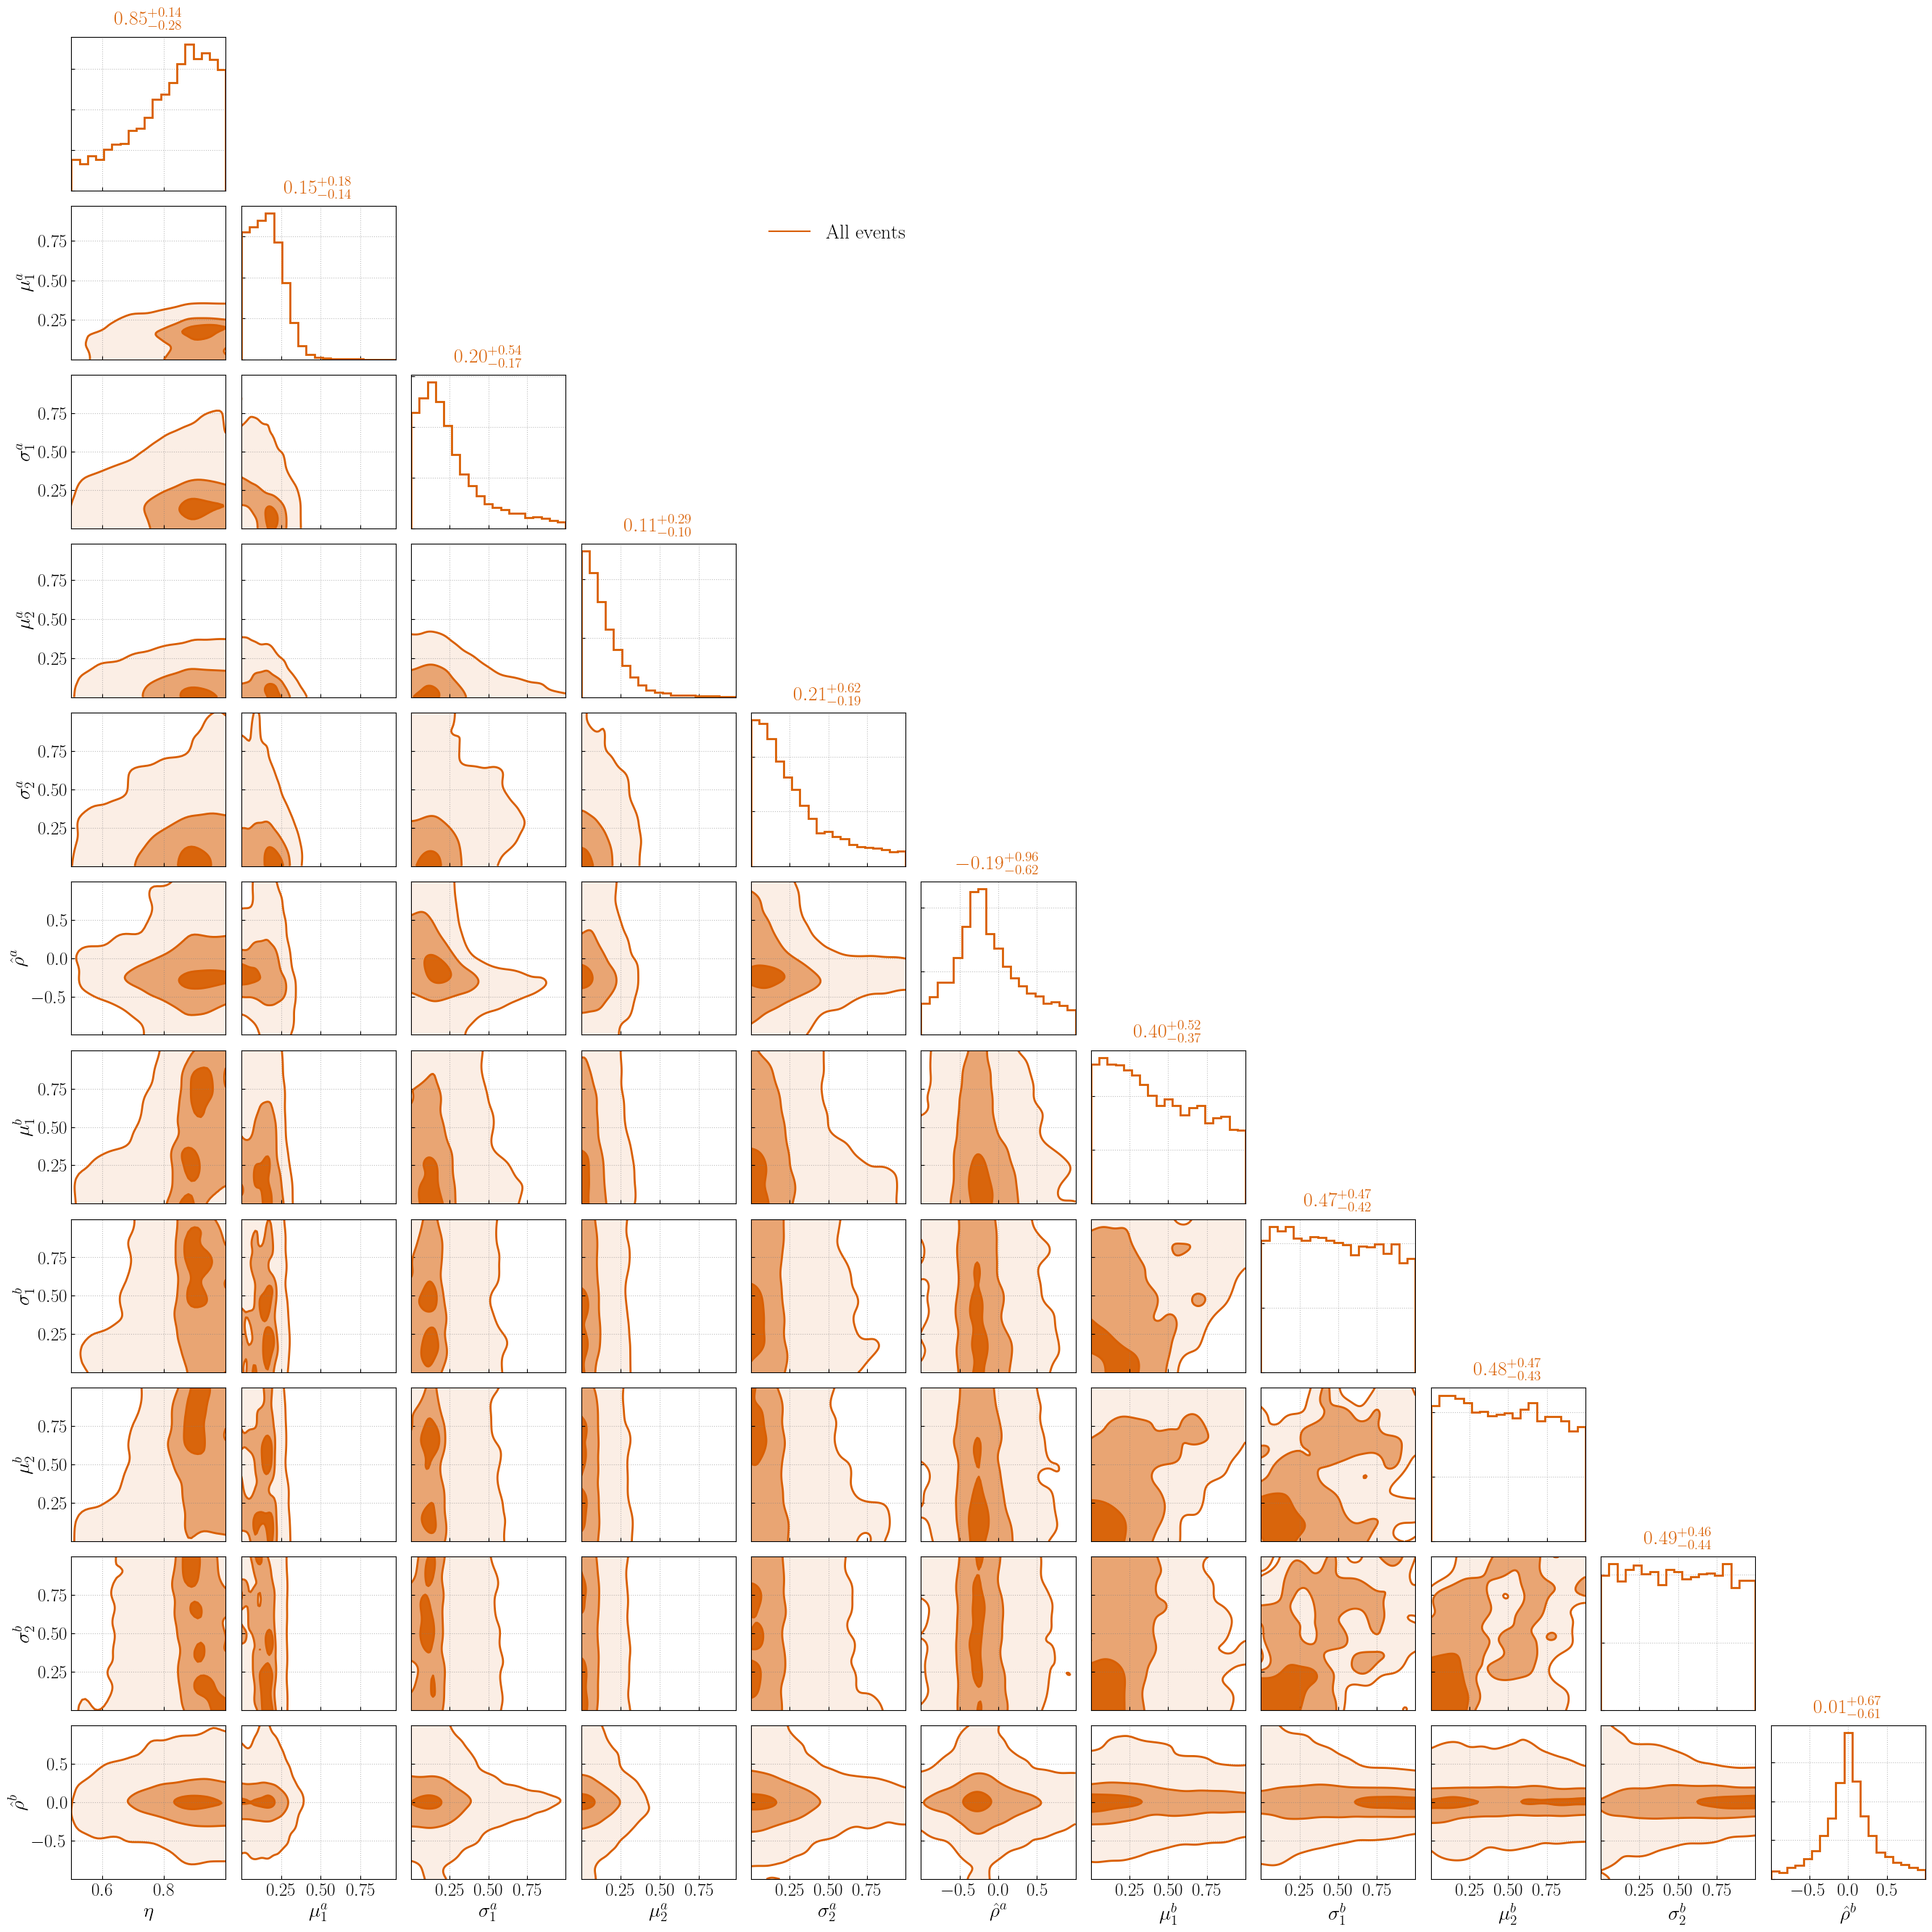

In [862]:
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

cond2 = np.ones_like(posterior_samples_no_190517['mu_chi_1'], dtype='bool')
#cond2 &= (posterior_samples_no_190517['eta_spin'] > np.percentile(posterior_samples_no_190517['eta_spin'], 10))

fig_corner, axes_corner = make_corner_plot(all_data=[makedict(posterior_samples_no_190517[cond])],
                 model_labels=['All events'],
                 variables=['eta_spin', 
                            'mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1_true', 
                            'mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2_true'],
                 variable_labels=[r'$\eta$', 
                                  r'$\mu^a_1$', r'$\sigma^a_1$', r'$\mu^a_2$', r'$\sigma^a_2$', r'$\hat{\rho}^a$',
                                  r'$\mu^b_1$', r'$\sigma^b_1$', r'$\mu^b_2$', r'$\sigma^b_2$', r'$\hat{\rho}^b$'],
                boundaries={'eta_spin' : [0,1]},
                kde=True, scatter=False, scatter_kwargs=dict(s=2), 
                boundary_bias=True, fill=True, quantiles=[0.9, 0.5, 0.1]);

#fig_corner.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/corner_all.pdf")

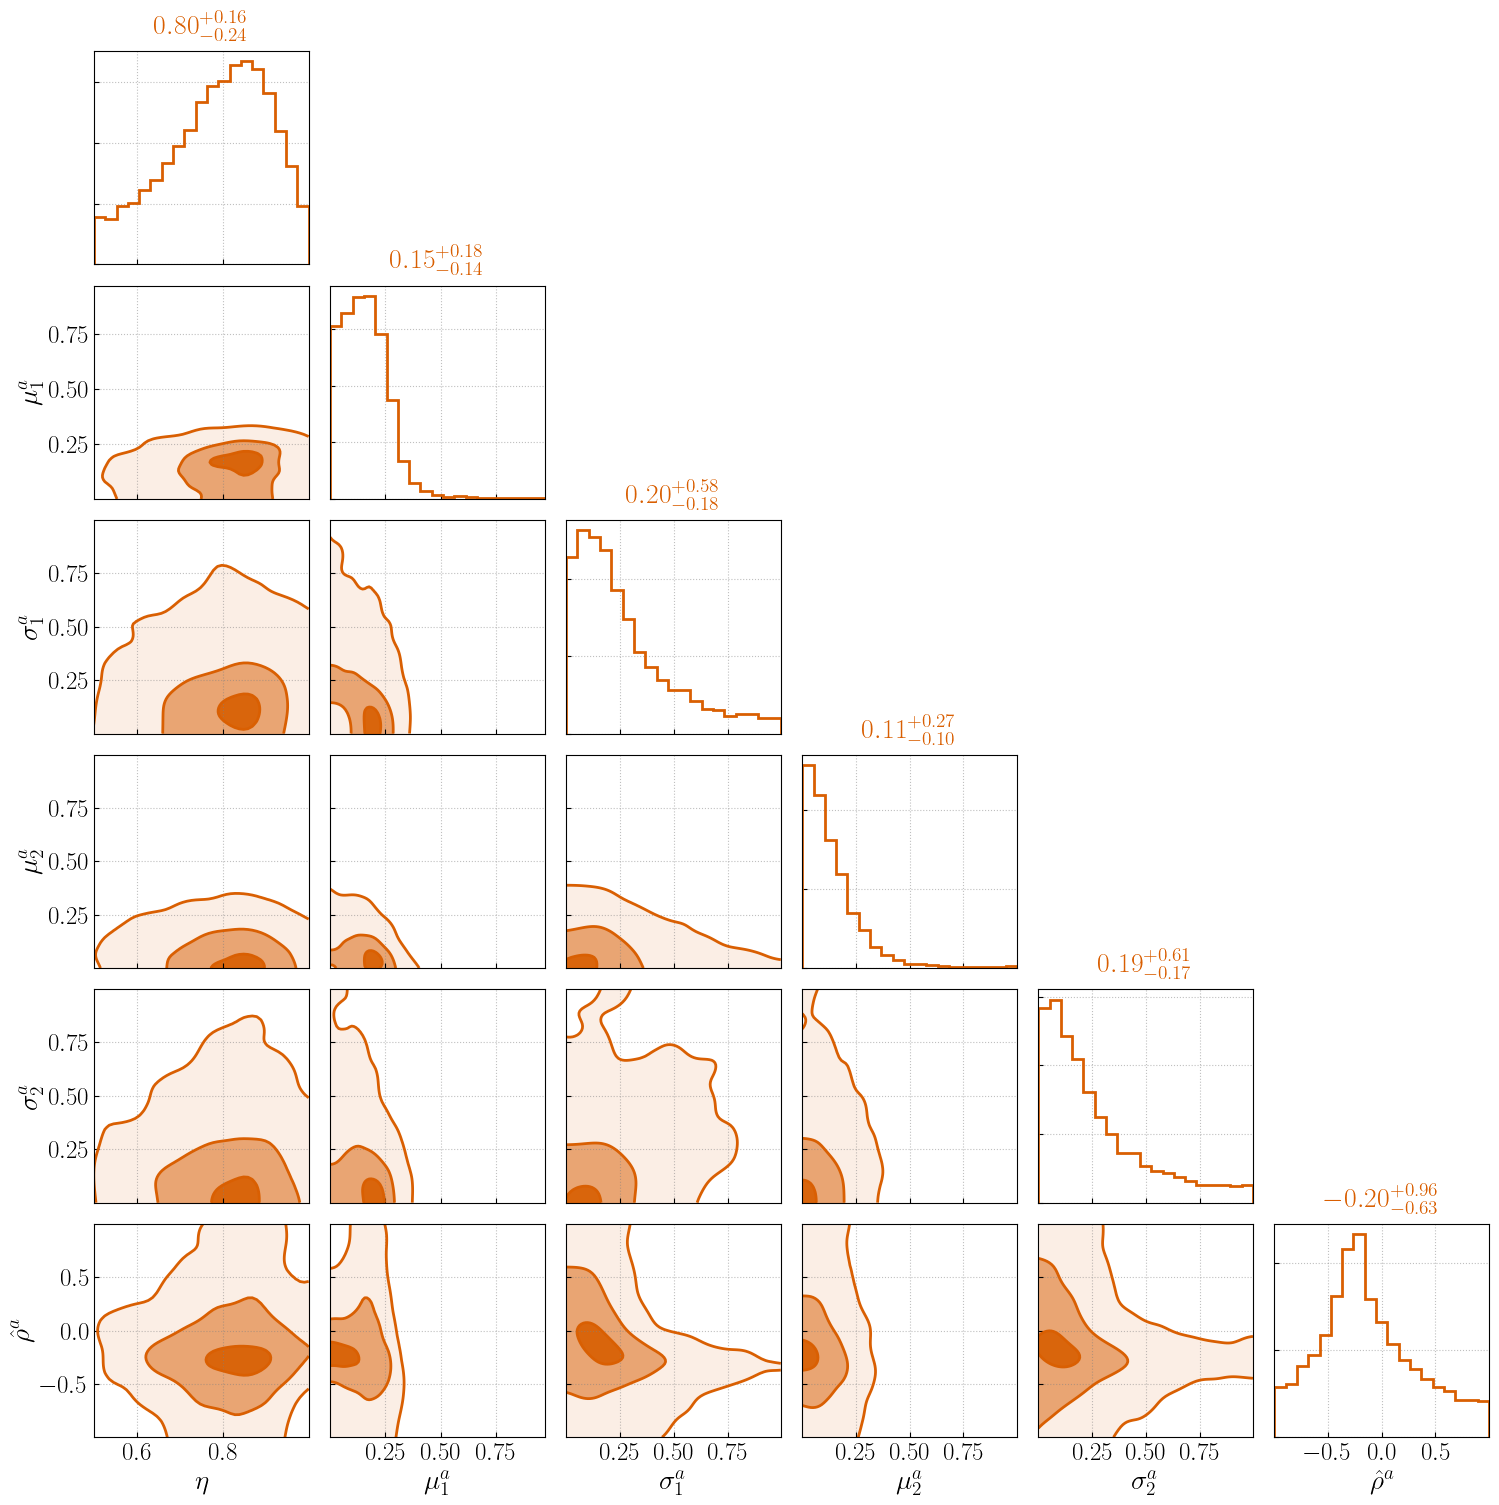

In [858]:
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

cond2 = np.ones_like(posterior_samples_no_190517['mu_chi_1'], dtype='bool')
#cond2 &= (posterior_samples_no_190517['eta_spin'] > np.percentile(posterior_samples_no_190517['eta_spin'], 10))

fig_corner, axes_corner = make_corner_plot(all_data=[makedict(posterior_samples[cond])],
                 model_labels=['All events'],
                 variables=['eta_spin', 
                            'mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1_true'],
                 variable_labels=[r'$\eta$', 
                                  r'$\mu^a_1$', r'$\sigma^a_1$', r'$\mu^a_2$', r'$\sigma^a_2$', r'$\hat{\rho}^a$'],
                boundaries={'eta_spin' : [0,1]}, legend=False,
                kde=True, scatter=False, scatter_kwargs=dict(s=2), 
                boundary_bias=True, fill=True, quantiles=[0.9, 0.5, 0.1]);

fig_corner.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/corner_component_1.pdf")

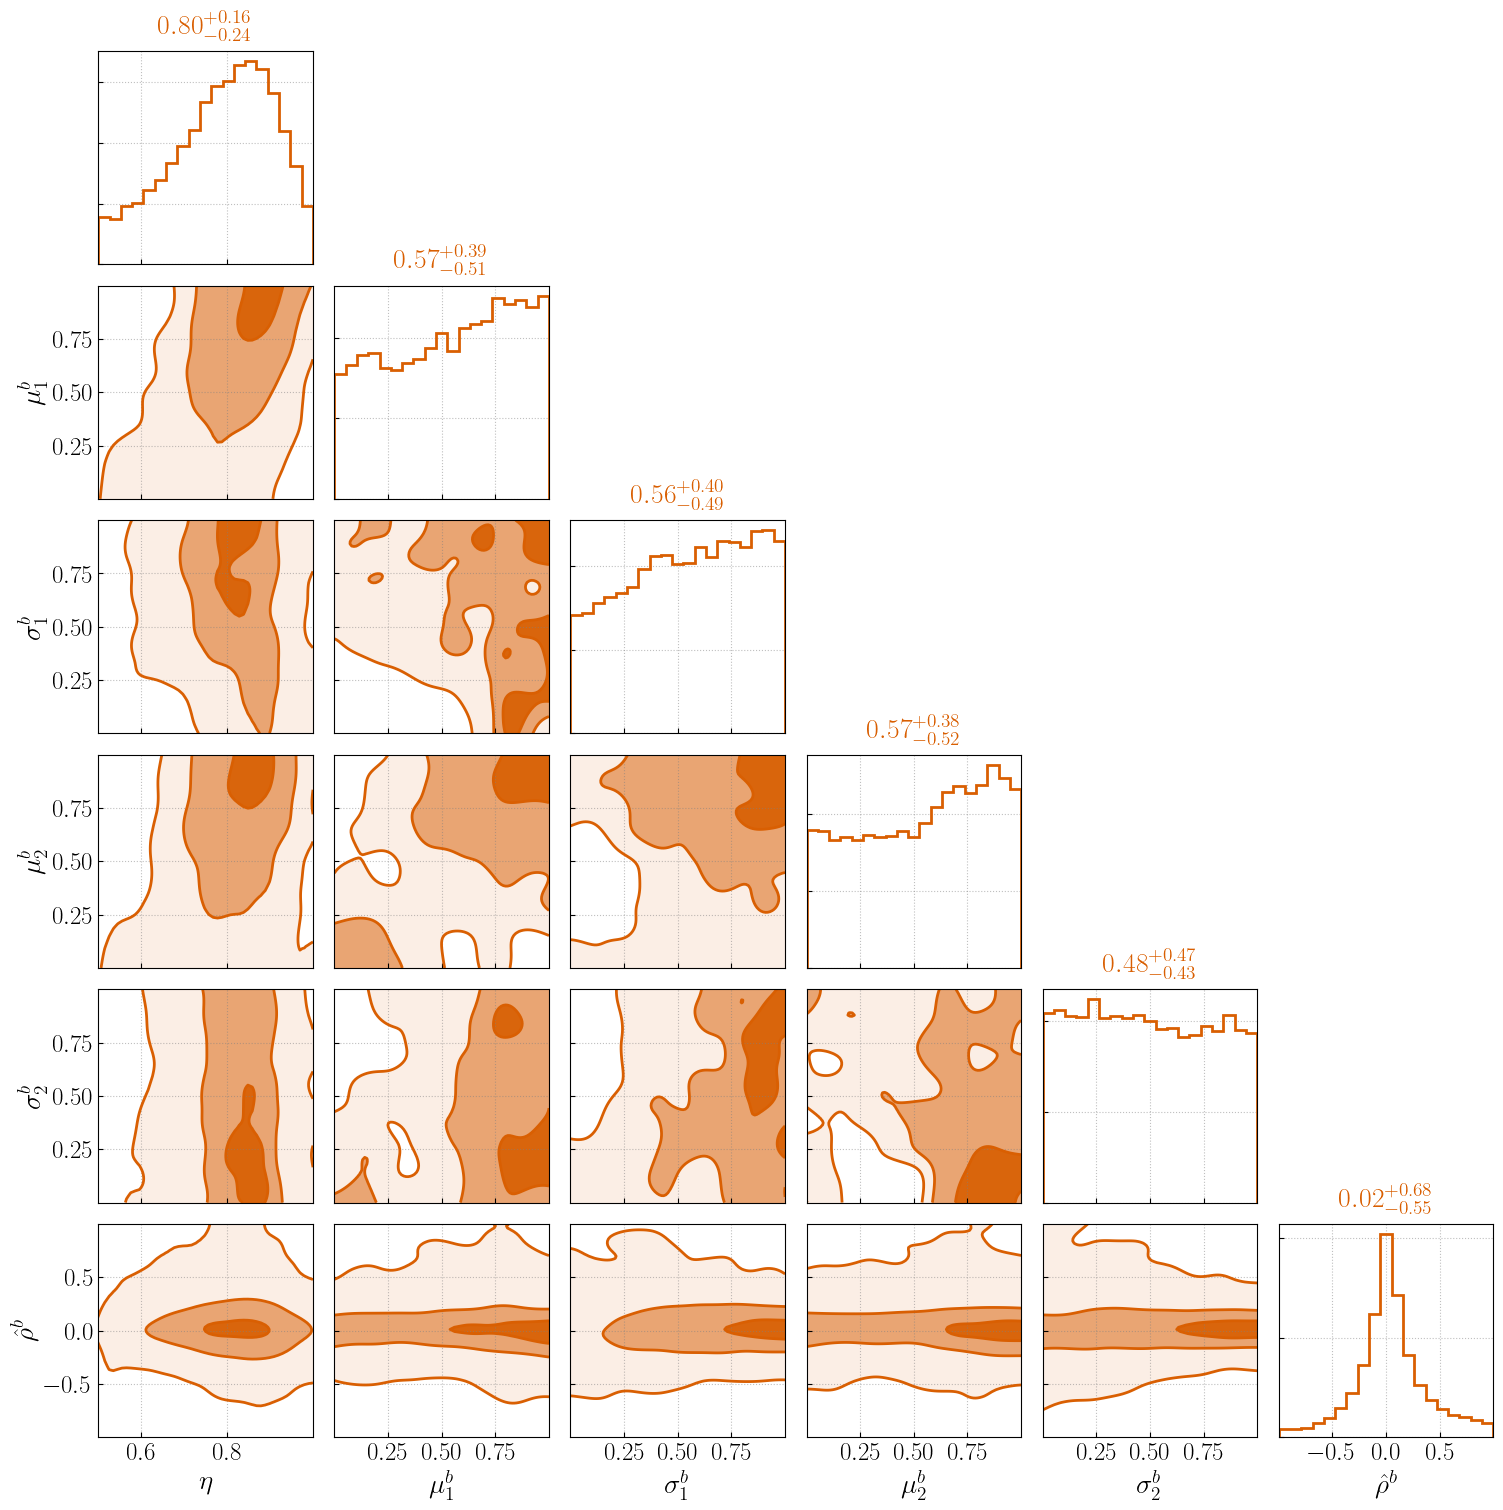

In [859]:
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

cond2 = np.ones_like(posterior_samples_no_190517['mu_chi_1'], dtype='bool')
#cond2 &= (posterior_samples_no_190517['eta_spin'] > np.percentile(posterior_samples_no_190517['eta_spin'], 10))

fig_corner, axes_corner = make_corner_plot(all_data=[makedict(posterior_samples[cond])],
                 model_labels=['All events'],
                 variables=['eta_spin', 
                            'mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2_true'],
                 variable_labels=[r'$\eta$', 
                                  r'$\mu^b_1$', r'$\sigma^b_1$', r'$\mu^b_2$', r'$\sigma^b_2$', r'$\hat{\rho}^b$'],
                boundaries={'eta_spin' : [0,1]}, legend=False,
                kde=True, scatter=False, scatter_kwargs=dict(s=2), 
                boundary_bias=True, fill=True, quantiles=[0.9, 0.5, 0.1]);


fig_corner.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/corner_component_2.pdf")

### Corner with $\eta_0$ in 90 percentile

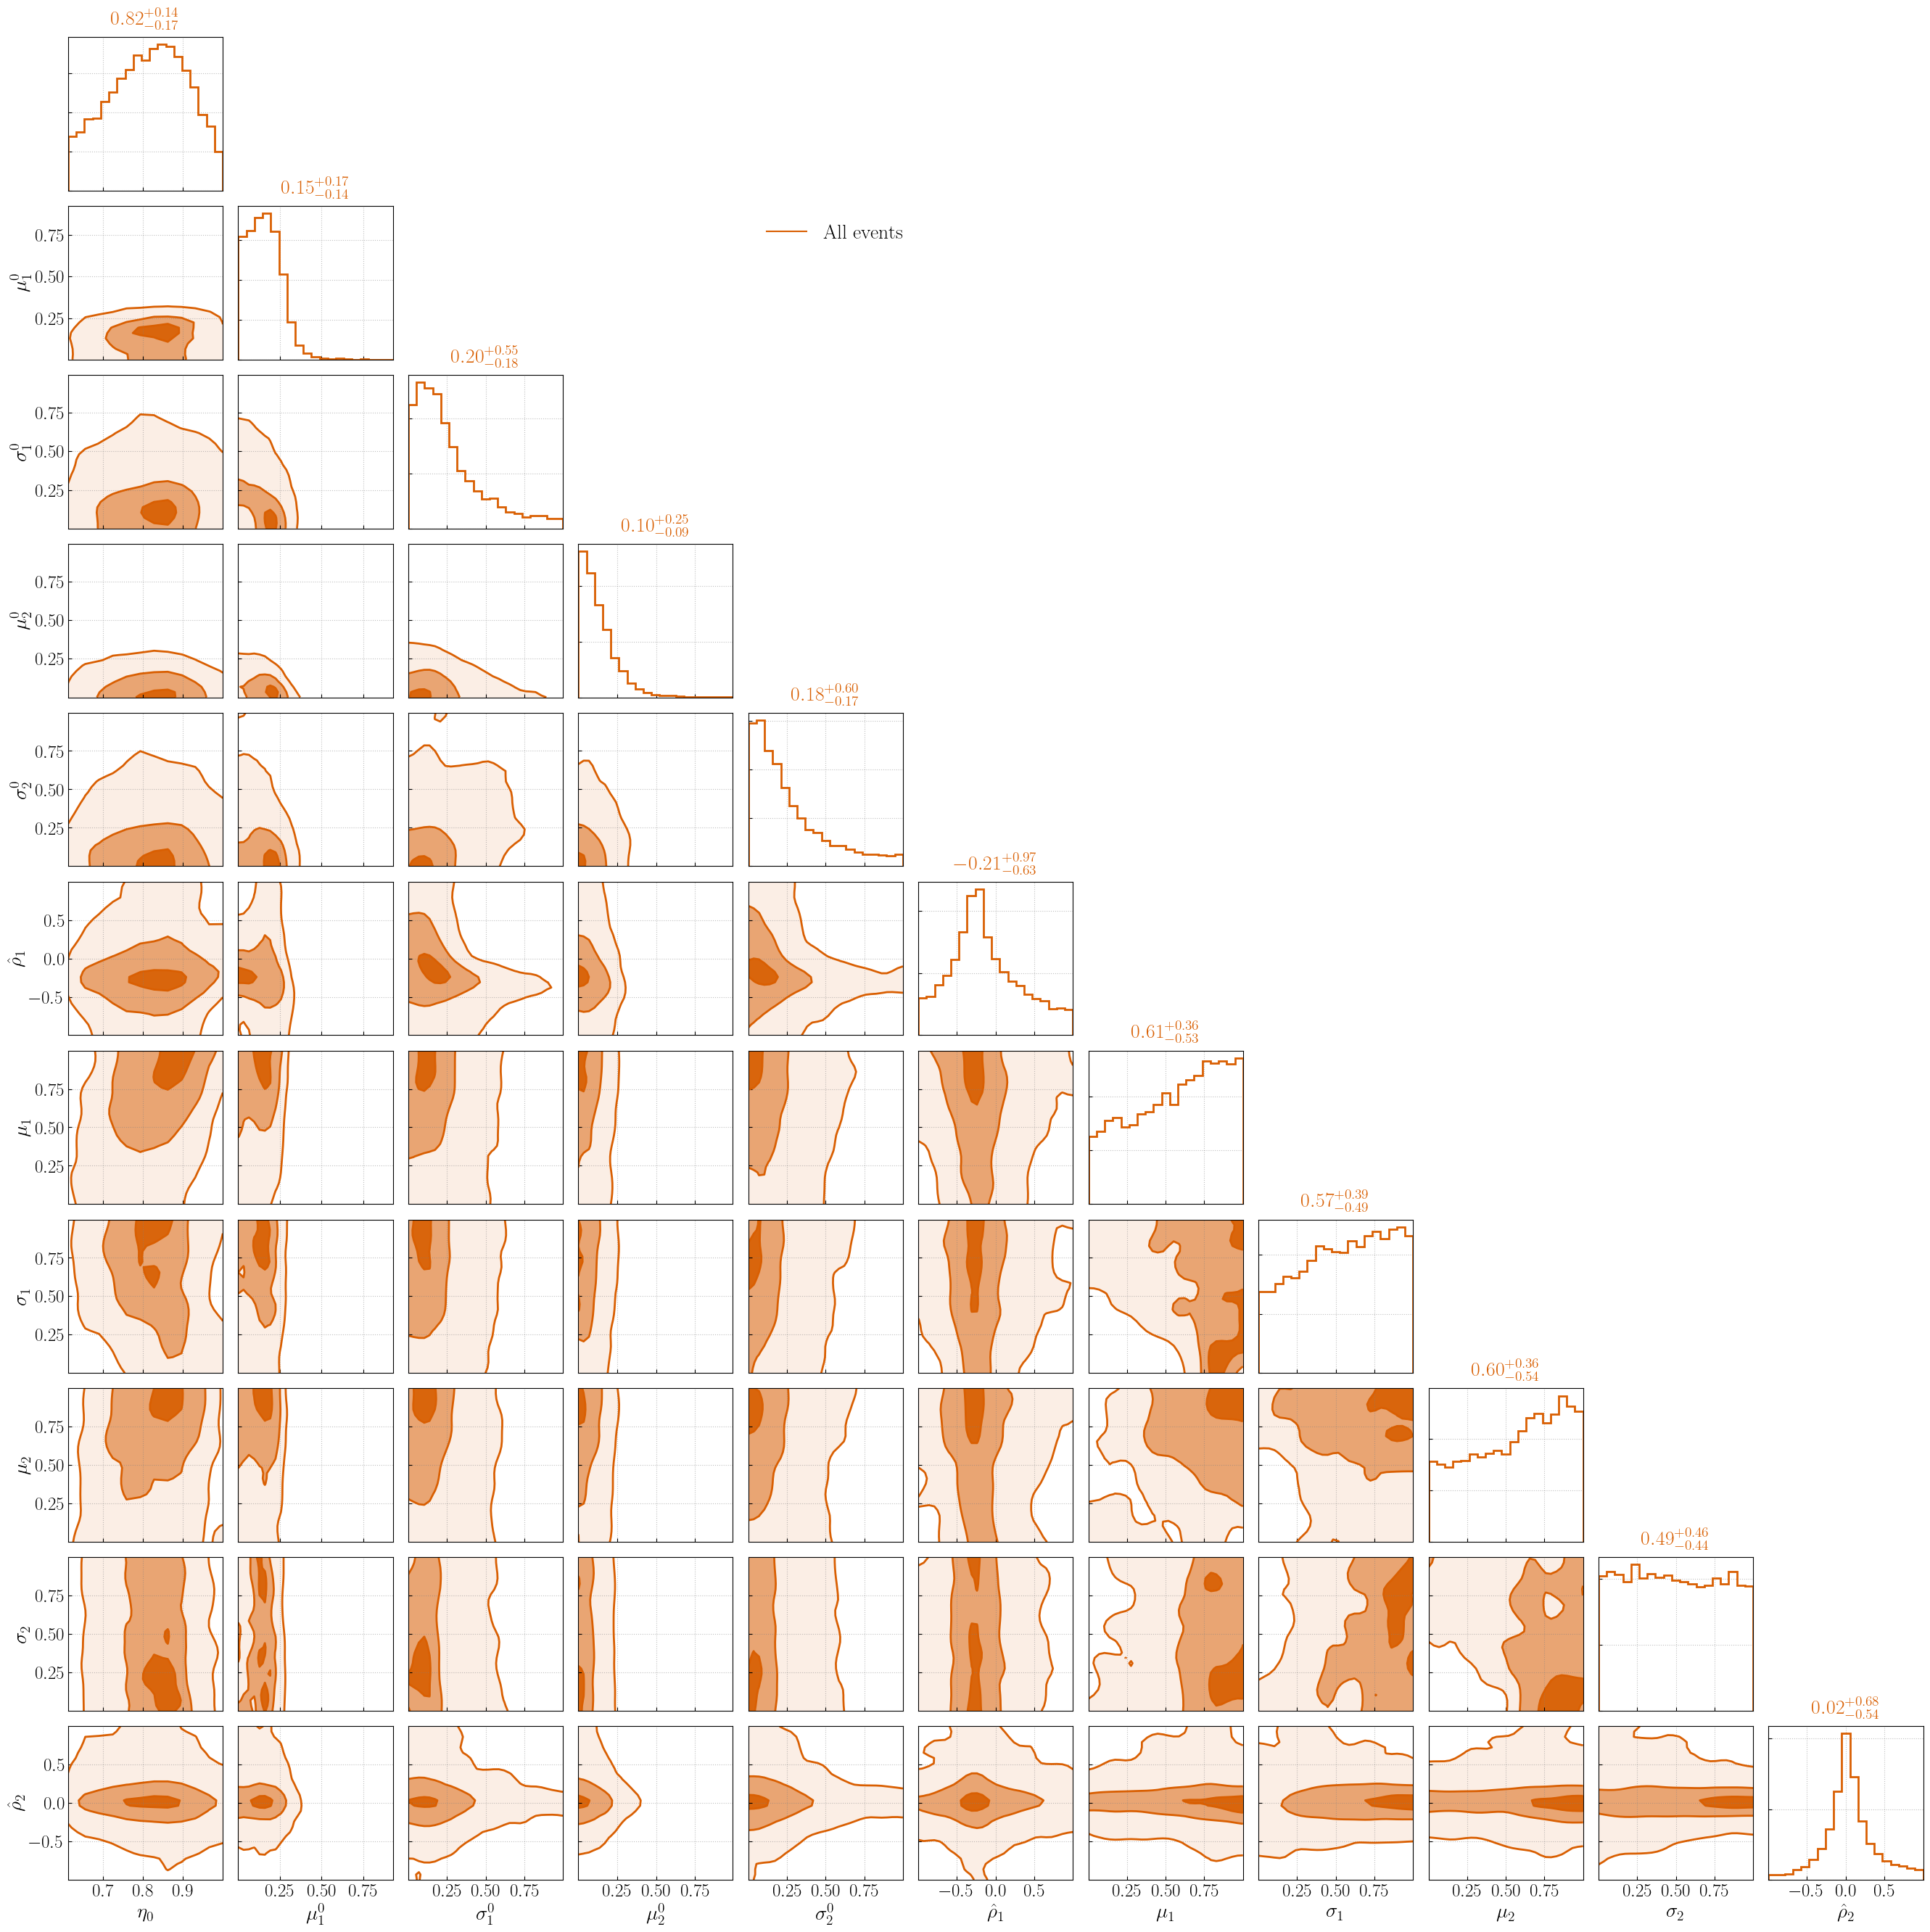

In [17]:
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

cond2 = np.ones_like(posterior_samples_no_190517['mu_chi_1'], dtype='bool')
cond2 &= (posterior_samples_no_190517['eta_spin'] > np.percentile(posterior_samples_no_190517['eta_spin'], 10))

fig_corner, axes_corner = make_corner_plot(all_data=[makedict(posterior_samples[cond])],
                 model_labels=['All events'],
                 variables=['eta_spin', 
                            'mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1_true', 
                            'mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2_true'],
                 variable_labels=[r'$\eta_{0}$', 
                                  r'$\mu^0_1$', r'$\sigma^0_1$', r'$\mu^0_2$', r'$\sigma^0_2$', r'$\hat{\rho}_1$',
                                  r'$\mu_1$', r'$\sigma_1$', r'$\mu_2$', r'$\sigma_2$', r'$\hat{\rho}_2$'],
                boundaries={'eta_spin' : [0,1]},
                kde=True, scatter=False, scatter_kwargs=dict(s=2), 
                boundary_bias=True, fill=True, quantiles=[0.9, 0.5, 0.1]);

## PPD with 90 percentile $\eta_0$

9000


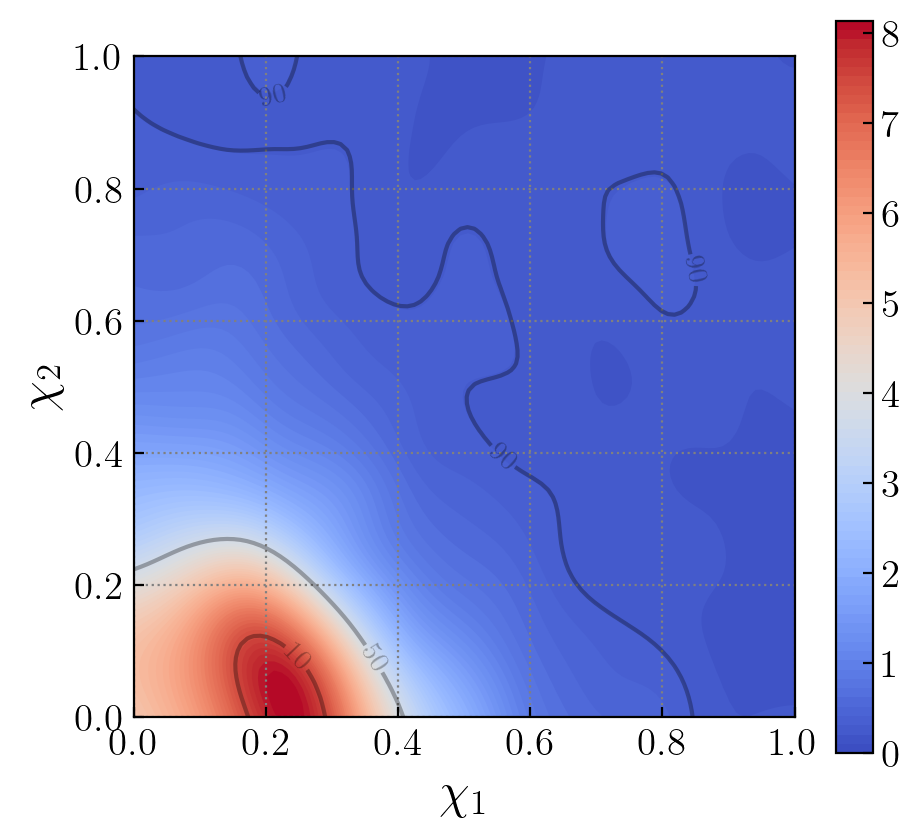

In [44]:
fig = SpinMagintudePlot(makedict(posterior_samples[posterior_samples['eta_spin'] > posterior_samples['eta_spin'].quantile(0.1)]), the_spin_magnitude_model_2D).spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()

## PPD

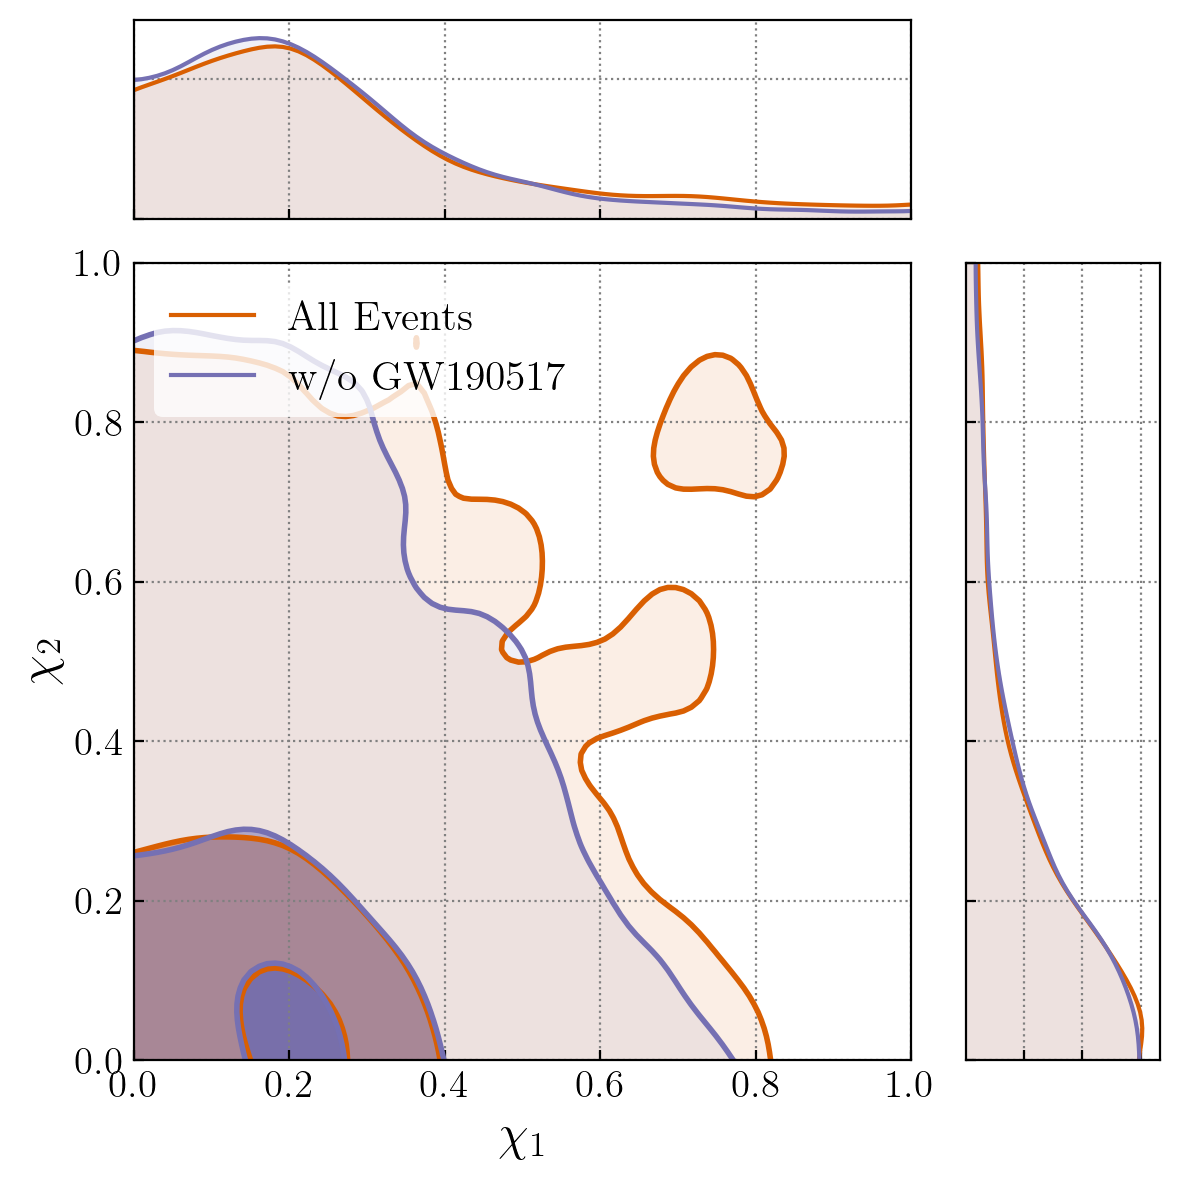

In [23]:
from truncnormkde import *
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 10_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 10_000 // len(posterior_samples_no_190517[cond])
dfsamps2 = the_spin_magnitude_model_2D.sample(posterior_samples_no_190517[cond], oversample=oversample)

fig = make_2D_comparison(dfsamps, dfsamps2, legend_location='upper left', quantiles=[0.9,0.5,0.1])

fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/PPD_on_top.pdf", bbox_inches='tight',dpi=200)

## PPD of the first:

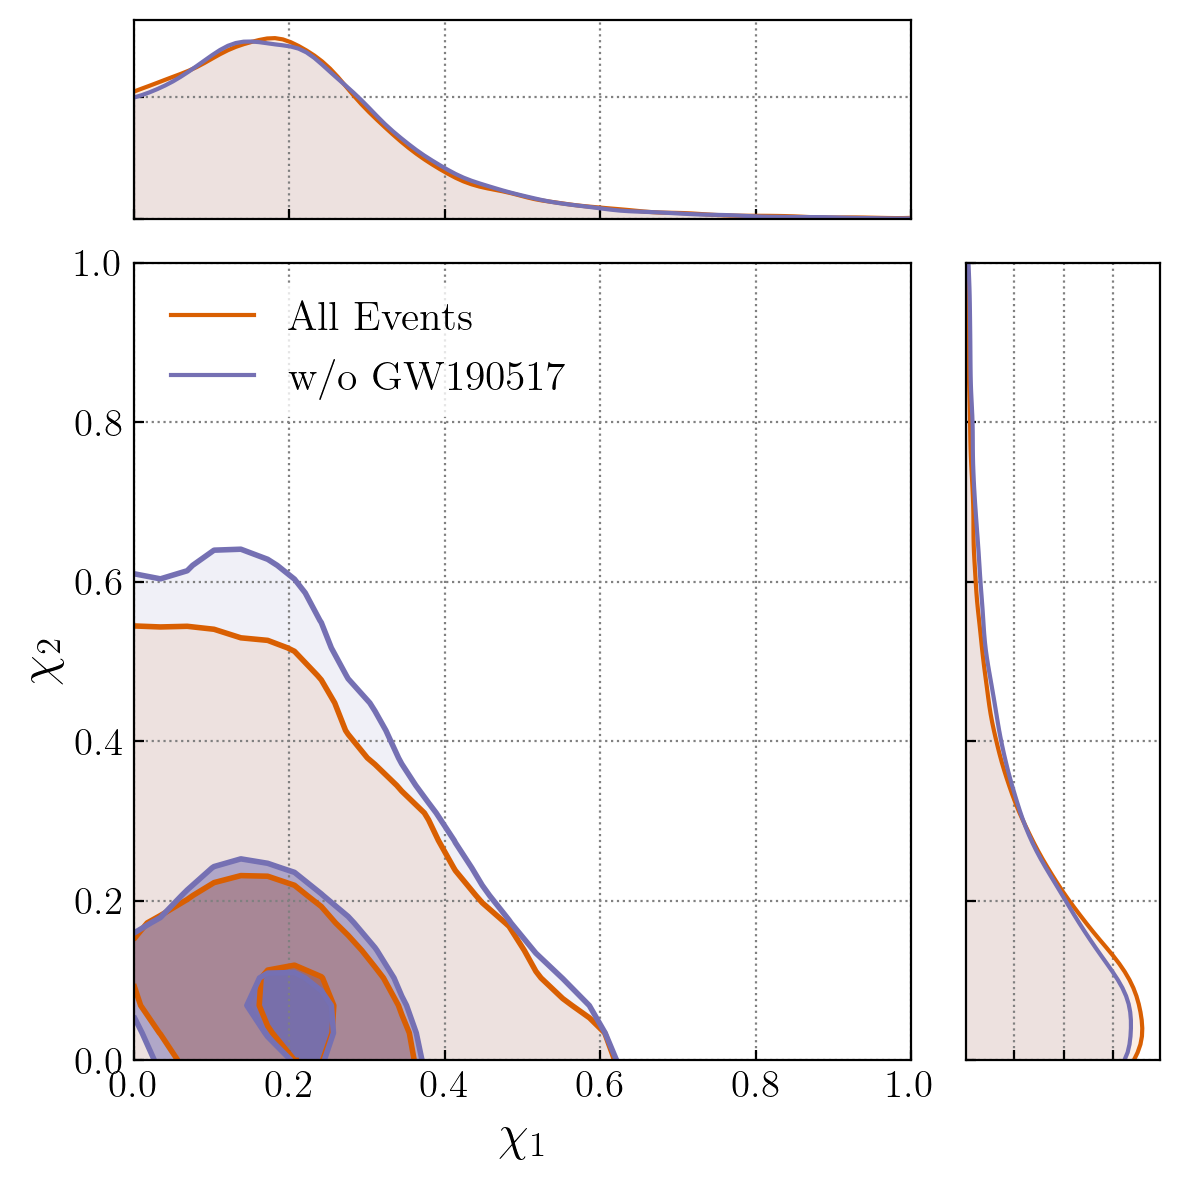

In [35]:
from truncnormkde import *
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.models[0].sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples_no_190517[cond])
dfsamps2 = the_spin_magnitude_model_2D.models[0].sample(posterior_samples_no_190517[cond], oversample=oversample)

fig = make_2D_comparison(dfsamps, dfsamps2, legend_location='upper left')

#fig.savefig(f"{root_folder}/figures/two_component_sigma_eta_corner_compared_190517.pdf", bbox_inches='tight',dpi=200)

9000


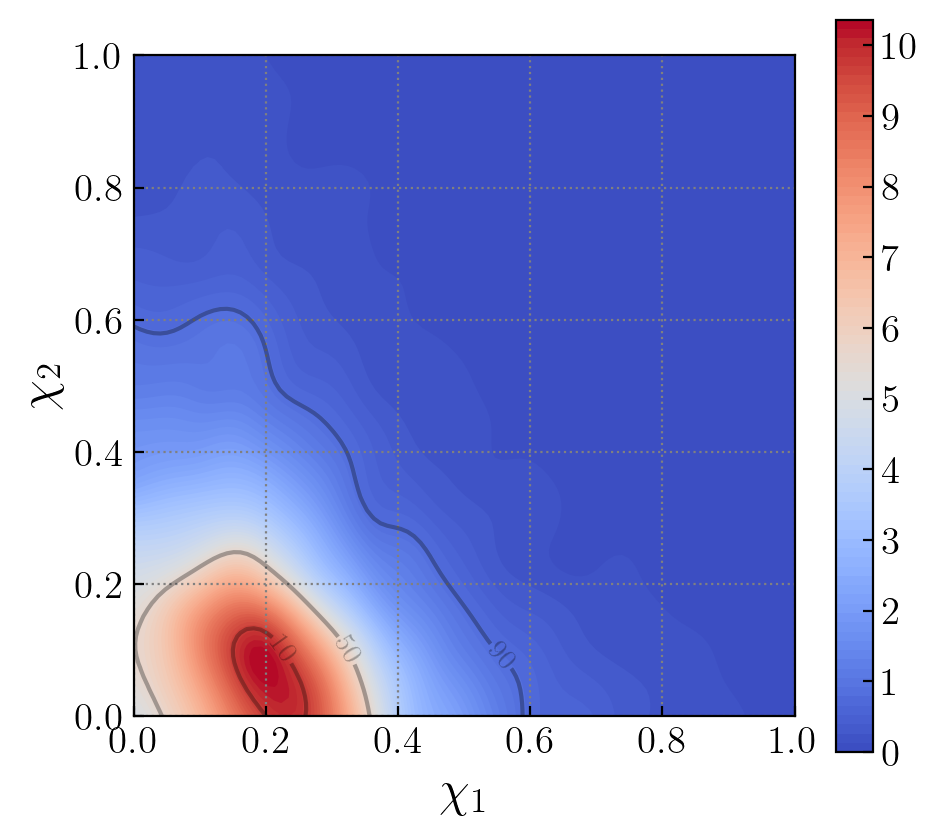

In [36]:
fig = SpinMagintudePlot(makedict(posterior_samples[posterior_samples['eta_spin'] > posterior_samples['eta_spin'].quantile(0.1)]), the_spin_magnitude_model_2D.models[0]).spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()

9000


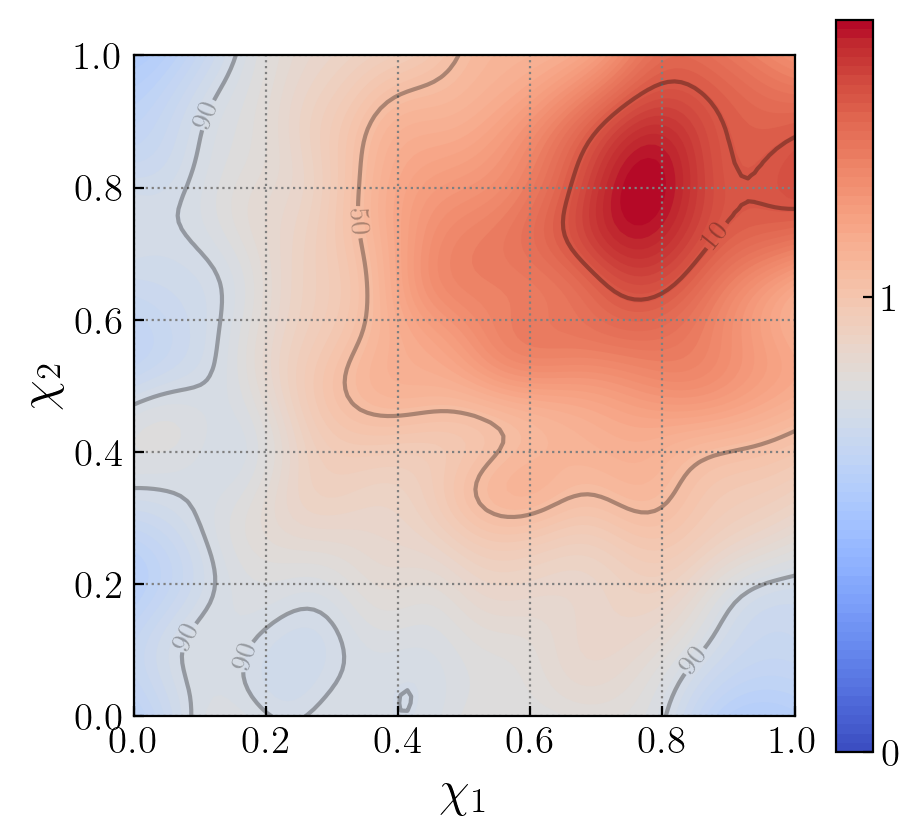

In [37]:
fig = SpinMagintudePlot(makedict(posterior_samples[posterior_samples['eta_spin'] > posterior_samples['eta_spin'].quantile(0.1)]), the_spin_magnitude_model_2D.models[1]).spin_2D_plot(quantiles=[0.9,0.5,0.1]);
fig.tight_layout()

## PPD of the second

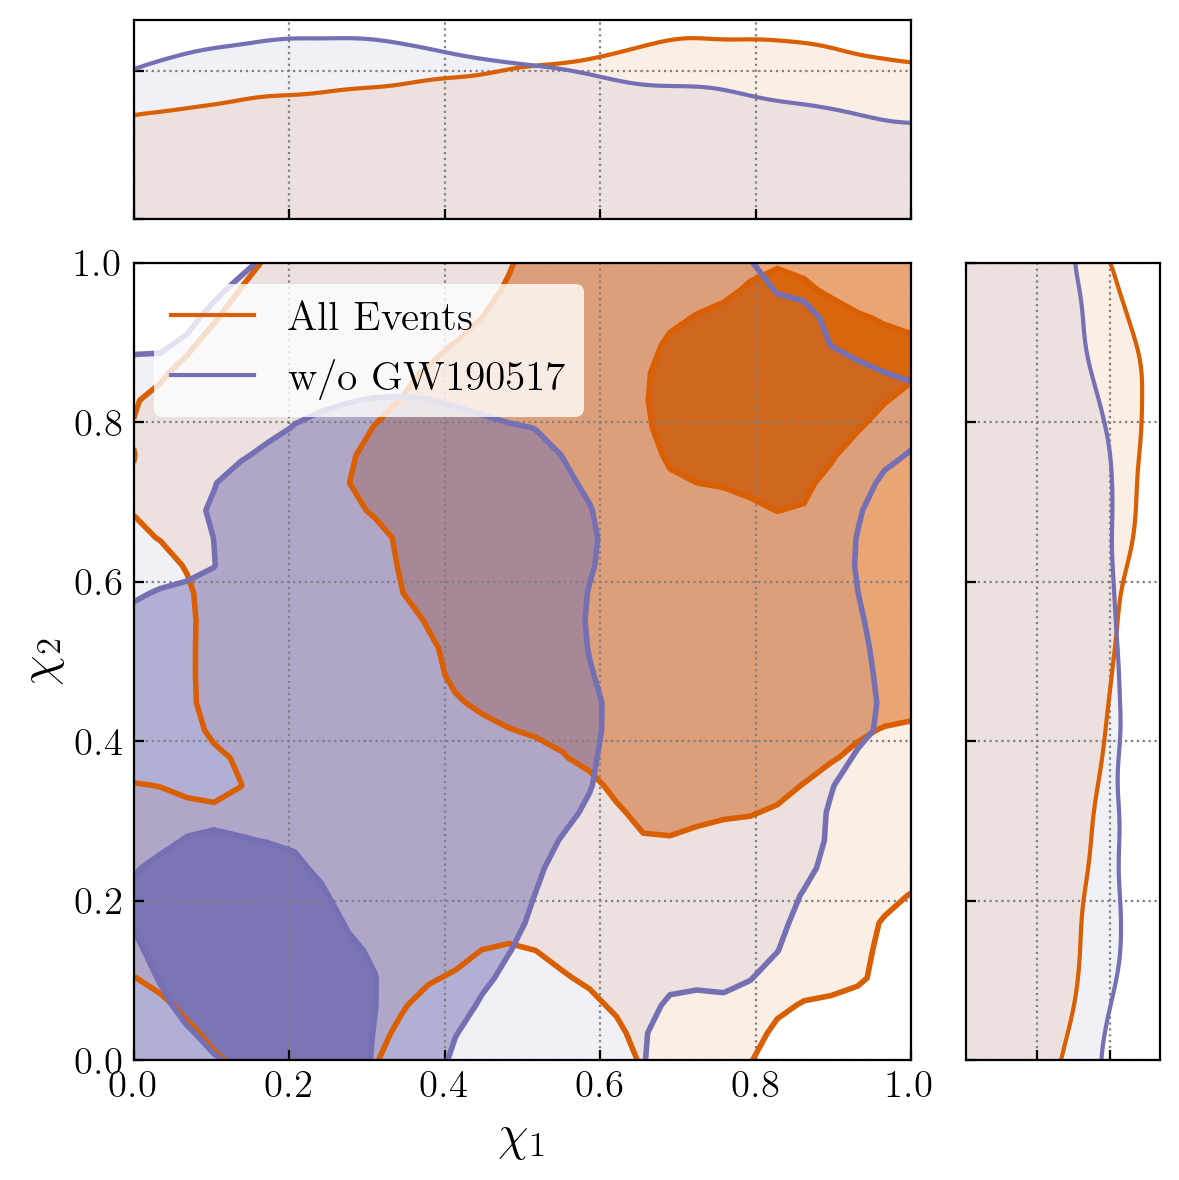

In [38]:
from truncnormkde import *
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.models[1].sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples_no_190517[cond])
dfsamps2 = the_spin_magnitude_model_2D.models[1].sample(posterior_samples_no_190517[cond], oversample=oversample)

fig = make_2D_comparison(dfsamps, dfsamps2, legend_location='upper left')

#fig.savefig(f"{root_folder}/figures/two_component_sigma_eta_corner_compared_190517.pdf", bbox_inches='tight',dpi=200)

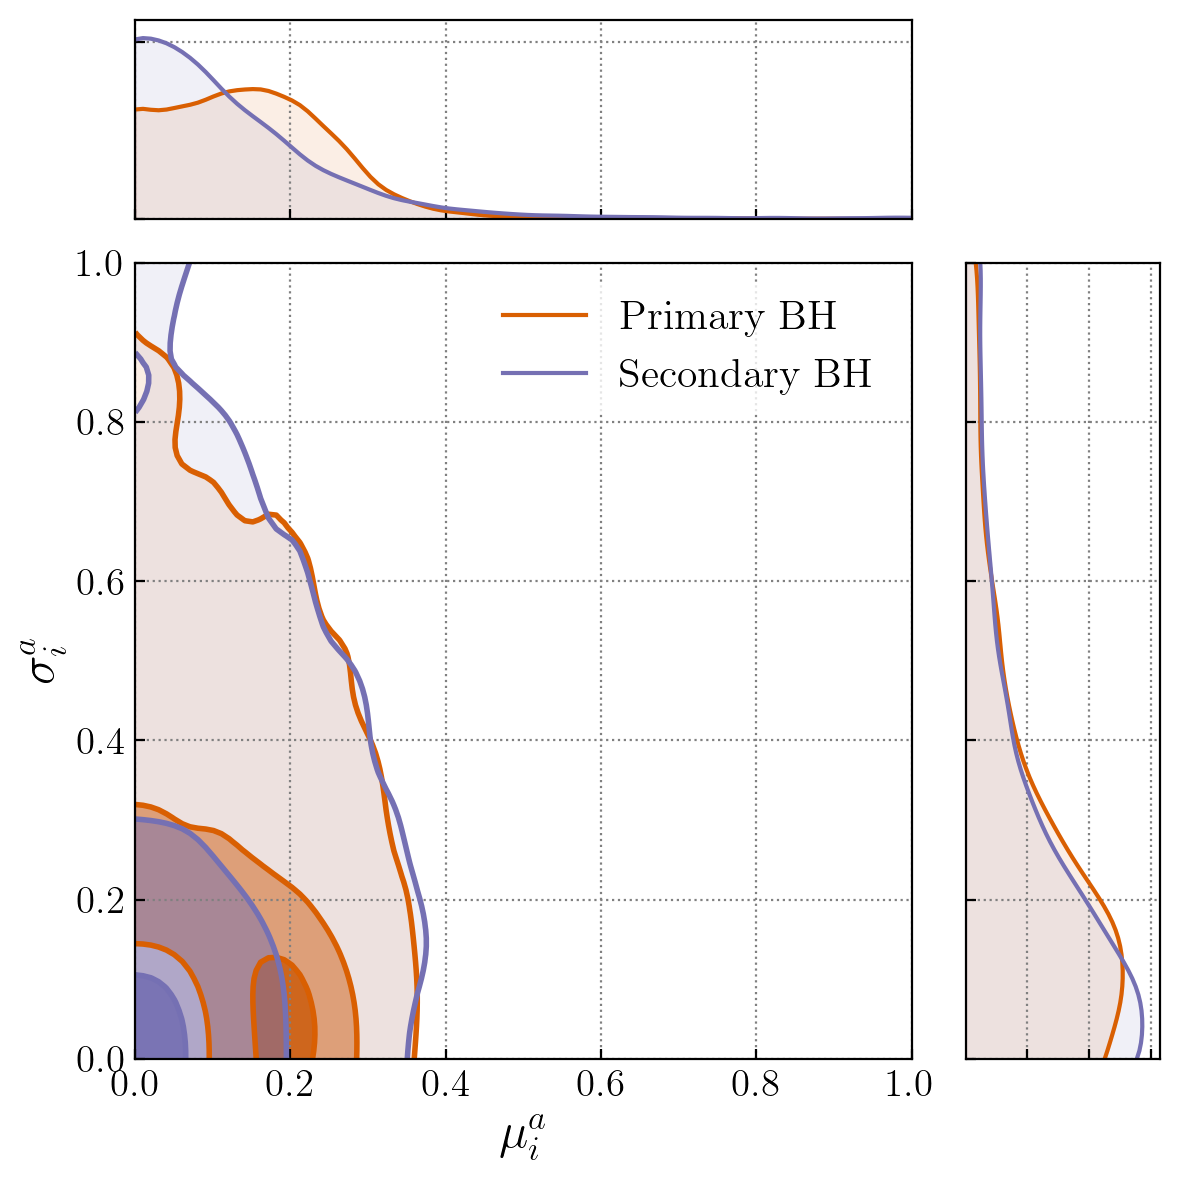

In [675]:
from truncnormkde import *
df1 = posterior_samples[['mu_chi_1_at_0', 'sigma_chi_1_at_0']].copy().rename({'mu_chi_1_at_0':'mu_chi', 'sigma_chi_1_at_0':'sigma_chi'},axis=1)
df2 = posterior_samples[['mu_chi_2_at_0', 'sigma_chi_2_at_0']].copy().rename({'mu_chi_2_at_0':'mu_chi', 'sigma_chi_2_at_0':'sigma_chi'},axis=1)

fig = make_2D_comparison(df1, df2, 
                         variables=['mu_chi', 'sigma_chi'],
                         variable_labels=[r'$\mu^{a}_i$', r'$\sigma^{a}_i$'],
                         legend_location='upper right', quantiles=[0.9,0.5,0.1],
                         model_labels=["Primary BH", "Secondary BH"])

#fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/Fixed/DominantComponentCorner.pdf", bbox_inches='tight',dpi=200)

In [ ]:
from truncnormkde import *

posts1 = posterior_samples.copy()
posts2 = posterior_samples.copy()
posts2 = 
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.models[0].sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples_no_190517[cond])
dfsamps2 = the_spin_magnitude_model_2D.models[0].sample(posterior_samples_no_190517[cond], oversample=oversample)

fig = make_2D_comparison(dfsamps, dfsamps2, legend_location='upper left')

#fig.savefig(f"{root_folder}/figures/two_component_sigma_eta_corner_compared_190517.pdf", bbox_inches='tight',dpi=200)

## Correlation of slowly spinning pop

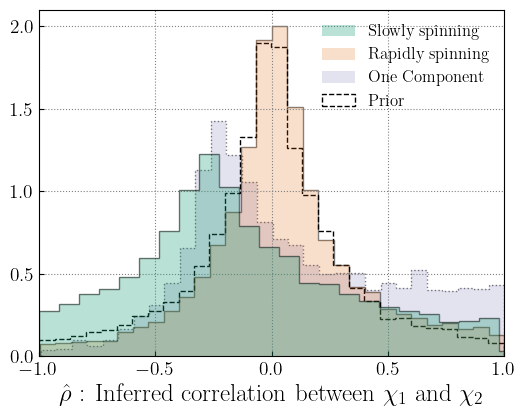

In [64]:
fig_corr, _ = plt.subplots(1);
#cond = (posterior_samples['eta_spin'] > 0.7)
plt.hist(posterior_samples['rho_chi_1_true'], bins=30, density=True, alpha=0.3, color=default_pallete[0], zorder=2, label="Slowly spinning")
plt.hist(posterior_samples['rho_chi_1_true'], bins=30, density=True, histtype='step', edgecolor='black', zorder=2, alpha=0.5)
plt.hist(posterior_samples['rho_chi_2_true'], bins=30, density=True, alpha=0.2, color=default_pallete[1], label="Rapidly spinning")
plt.hist(posterior_samples['rho_chi_2_true'], bins=30, density=True, histtype='step', edgecolor='black', zorder=0, alpha=0.5)
plt.hist(posterior_one_component_samples['rho_chi_true'], bins=30, density=True, alpha=0.2, color=default_pallete[2],  zorder=-1, label="One Component")
plt.hist(posterior_one_component_samples['rho_chi_true'], bins=30, density=True, histtype='step', edgecolor='black', linestyle="dotted", zorder=-1, alpha=0.5)
plt.hist(prior_samples['rho_chi_1_true'], bins=30, density=True, histtype='step', edgecolor='black', zorder=0, alpha=1, linewidth=1, linestyle='dashed', label="Prior")
plt.legend(fontsize=12)
plt.xlim(-1,1);
plt.xlabel(r"$\hat{\rho}$ : Inferred correlation between $\chi_1$ and $\chi_2$")
plt.show()

fig_corr.savefig(f"{root_folder}/figures/TwoComponent/Correlated/correlation.pdf", bbox_inches='tight',dpi=200)

## Bayes Factors

In [7]:
import pandas as pd
dff = pd.read_csv(f"{root_folder}/data/misc/Two_General_Components_BayesFactors.csv")
posterior_samples_2 = pd.read_csv(f"{root_folder}/data/hyper_posterior_samples/TwoComponent/Two-Component-GenerallyFree.csv")
n_events = dff.event.nunique();

dff2 = pd.concat([posterior_samples_2]*n_events);
dff2.loc[:, 'event'] = dff['event'].values;
dff2.loc[:, 'lnBayes'] = dff['lnBayes'].values;
dff2.loc[:, 'BayesFactor'] = np.exp(dff2.loc[:, 'lnBayes'])
dff2.loc[:, 'BayesFactorCorrected'] = dff2.loc[:, 'BayesFactor'] * (1 - dff2.loc[:, 'eta_spin']) / dff2.loc[:, 'eta_spin'];
dff2.loc[:, 'lnBayesFactorCorrected'] = np.log(dff2.loc[:, 'BayesFactorCorrected']);
dff2 = dff2.reset_index()

# Define a custom bootstrapping function for the 90% confidence interval
def bootstrap_ci(series, n_bootstrap=1000, ci=90):
    # Generate bootstrap samples and calculate the mean for each sample
    bootstrap_samples = [series.sample(frac=1, replace=True).mean() for _ in range(n_bootstrap)]
    # Calculate the lower and upper percentiles for the confidence interval
    lower_bound = np.percentile(bootstrap_samples, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrap_samples, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

# Apply groupby with the custom aggregation
bayes_factors = (
    dff2.groupby('event').lnBayesFactorCorrected.agg(
        LogBayesFactorMean='mean',
        LogBayesFactorLowerCI=lambda x: bootstrap_ci(x)[0],
        LogBayesFactorUpperCI=lambda x: bootstrap_ci(x)[1]
    ).reset_index()
)

# Exponentiate the LogBayesFactor columns to get the normal BayesFactor columns
bayes_factors['BayesFactorMean'] = np.exp(bayes_factors['LogBayesFactorMean'])
bayes_factors['BayesFactor'] = bayes_factors['BayesFactorMean']
bayes_factors['BayesFactorLowerCI'] = np.exp(bayes_factors['LogBayesFactorLowerCI'])
bayes_factors['BayesFactorUpperCI'] = np.exp(bayes_factors['LogBayesFactorUpperCI'])

#bayes_factors_mean = dff2.groupby('event').lnBayesFactorCorrected.mean().apply(np.exp).reset_index().rename({'lnBayesFactorCorrected' : 'BayesFactor'}, axis=1);
#bayes_factors = dff2.groupby('event').BayesFactorCorrected.mean().reset_index().rename({'BayesFactorCorrected' : 'BayesFactor'}, axis=1);

from tqdm.notebook import tqdm

samples_dict = load_hdf5_to_jax_dict(f"{root_folder}/data/posterior_samples/all_event_samples.hdf5");

bfs = [];
for i,x in bayes_factors.iterrows():
    mean_values = pd.DataFrame(samples_dict[x['event']]).mean().to_dict();
    mean_values['event'] = x['event']
    mean_values['bayes_factors_mean'] = x['BayesFactorMean']
    mean_values['bayes_factors_mean_upperCI'] = x['BayesFactorUpperCI']
    mean_values['bayes_factors_mean_lowerCI'] = x['BayesFactorLowerCI']
    bfs.append(mean_values)


bfs = pd.DataFrame(bfs)

import pandas as pd
dff3 = pd.read_csv(f"{root_folder}/data/misc/Two_General_Components_BayesFactors_orientation.csv")

n_events = dff.event.nunique();

dff4 = pd.concat([posterior_samples_2]*n_events);
dff4.loc[:, 'event'] = dff3['event'].values;
dff4.loc[:, 'lnBayes'] = -dff3['lnBayes'].values; # Negative sign to correct for xi_spin = 1 => aligned
dff4.loc[:, 'BayesFactor'] = np.exp(dff4.loc[:, 'lnBayes'])
dff4.loc[:, 'BayesFactorCorrected'] = dff4.loc[:, 'BayesFactor'];
dff4.loc[:, 'lnBayesFactorCorrected'] = np.log(dff4.loc[:, 'BayesFactorCorrected']);
dff4 = dff4.reset_index()

# Define a custom bootstrapping function for the 90% confidence interval
def bootstrap_ci(series, n_bootstrap=1000, ci=90):
    # Generate bootstrap samples and calculate the mean for each sample
    bootstrap_samples = [series.sample(frac=1, replace=True).mean() for _ in range(n_bootstrap)]
    # Calculate the lower and upper percentiles for the confidence interval
    lower_bound = np.percentile(bootstrap_samples, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrap_samples, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

# Apply groupby with the custom aggregation
bayes_factors2 = (
    dff4.groupby('event').lnBayesFactorCorrected.agg(
        LogBayesFactorMean='mean',
        LogBayesFactorLowerCI=lambda x: bootstrap_ci(x)[0],
        LogBayesFactorUpperCI=lambda x: bootstrap_ci(x)[1]
    ).reset_index()
)

# Exponentiate the LogBayesFactor columns to get the normal BayesFactor columns
bayes_factors2['BayesFactorMean'] = np.exp(bayes_factors2['LogBayesFactorMean'])
bayes_factors2['BayesFactor'] = bayes_factors2['BayesFactorMean']
bayes_factors2['BayesFactorLowerCI'] = np.exp(bayes_factors2['LogBayesFactorLowerCI'])
bayes_factors2['BayesFactorUpperCI'] = np.exp(bayes_factors2['LogBayesFactorUpperCI'])


#bayes_factors2 = dff4.groupby('event').BayesFactorCorrected.mean().reset_index().rename({'BayesFactorCorrected' : 'BayesFactor'}, axis=1);
#bayes_factors2_mean = dff4.groupby('event').lnBayesFactorCorrected.mean().apply(np.exp).reset_index().rename({'lnBayesFactorCorrected' : 'BayesFactor'}, axis=1);

from tqdm.notebook import tqdm

samples_dict = load_hdf5_to_jax_dict(f"{root_folder}/data/posterior_samples/all_event_samples.hdf5");

bfs_orient = [];
for i,x in bayes_factors2.iterrows():
    mean_values = pd.DataFrame(samples_dict[x['event']]).mean().to_dict();
    mean_values['event'] = x['event']
    mean_values['bayes_factors_mean'] = x['BayesFactorMean']
    mean_values['bayes_factors_mean_upperCI'] = x['BayesFactorUpperCI']
    mean_values['bayes_factors_mean_lowerCI'] = x['BayesFactorLowerCI']
    bfs_orient.append(mean_values)

bfs_orient = pd.DataFrame(bfs_orient)

In [40]:
(np.log10(bfs['bayes_factors_mean_upperCI']) - np.log10(bfs['bayes_factors_mean_lowerCI'])).max()

0.1577320920142098

In [41]:
(np.log10(bfs_orient['bayes_factors_mean_upperCI']) - np.log10(bfs_orient['bayes_factors_mean_lowerCI'])).max()

0.02859705724379069

['GW190517_055101' 'GW190519_153544' 'GW190706_222641' 'GW190805_211137'
 'GW191109_010717' 'GW190620_030421' 'GW200129_065458' 'GW170729']


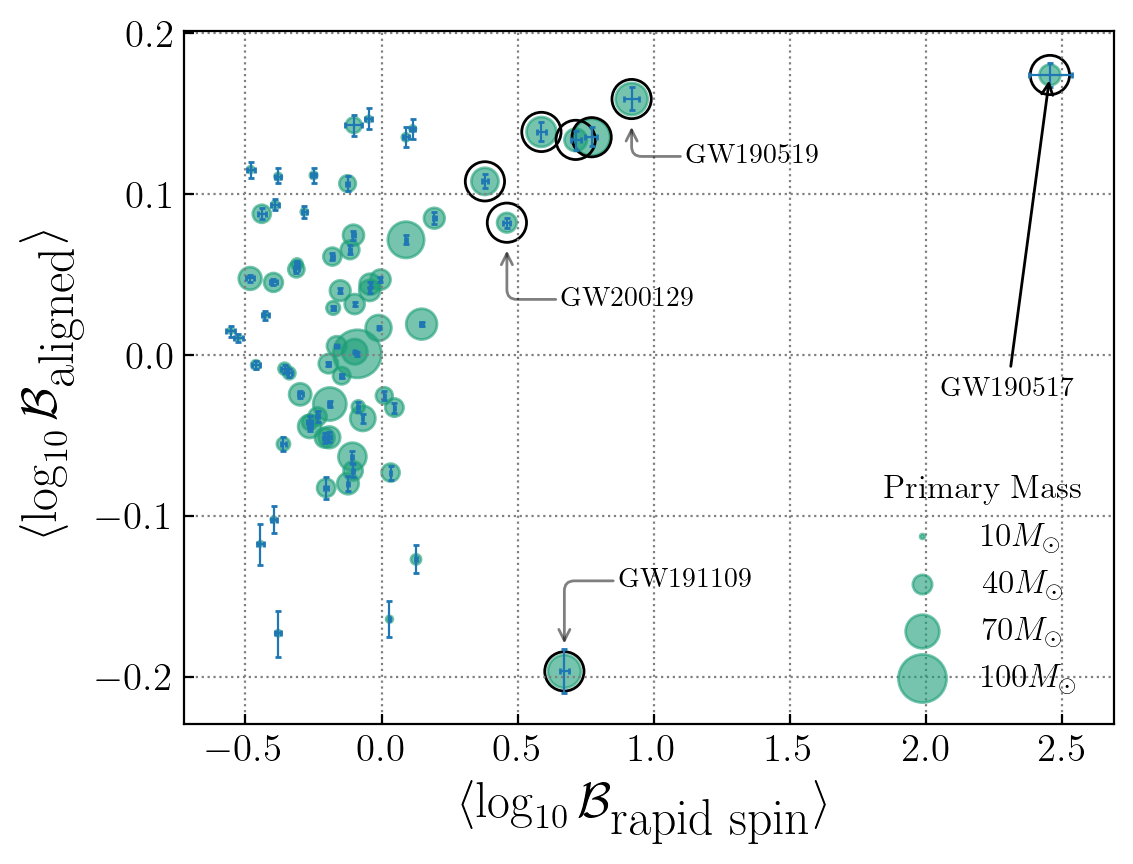

In [35]:
maxmass = bfs_orient['mass_1_source'].max()
masses = bfs_orient['mass_1_source']

marker_scale = 300
expon = 2

normed_mass = masses**expon/(maxmass**expon)

fig, ax = plt.subplots(1, dpi=200)
ax.scatter(np.log10(bfs['bayes_factors_mean']), np.log10(bfs_orient['bayes_factors_mean']), 
            s=normed_mass * marker_scale, alpha=0.6, color=default_pallete[0])
plt.errorbar(np.log10(bfs['bayes_factors_mean']), np.log10(bfs_orient['bayes_factors_mean']),
             xerr=[(np.log10(bfs['bayes_factors_mean']) - np.log10(bfs['bayes_factors_mean_lowerCI'])).values,
                   (np.log10(bfs['bayes_factors_mean_upperCI']) - np.log10(bfs['bayes_factors_mean'])).values],
             label='', capsize=1, fmt='none', linewidth=0.8)

plt.errorbar(np.log10(bfs['bayes_factors_mean']), np.log10(bfs_orient['bayes_factors_mean']),
             yerr=[np.log10(bfs_orient['bayes_factors_mean']) - np.log10(bfs_orient['bayes_factors_mean_lowerCI']),
                   np.log10(bfs_orient['bayes_factors_mean_upperCI']) - np.log10(bfs_orient['bayes_factors_mean'])],
             label='', capsize=1, fmt='none', linewidth=0.8)

plt.xlabel(r'$ \langle \log_{10} \mathcal{B}_{\textrm{rapid spin}} \rangle$');
plt.ylabel(r'$ \langle \log_{10} \mathcal{B}_{\textrm{aligned}} \rangle$');

for mass, size in zip(np.linspace(10,100,4), marker_scale*np.linspace(10,100,4)**2/100**2):
    plt.scatter([], [], s=size, color=default_pallete[0], alpha=0.6, label=f'${mass:.0f}' + r' M_{\odot}$')

# Add legend
plt.legend(title=r'Primary Mass', scatterpoints=1, loc='lower right', fontsize='large', title_fontsize='large')
#plt.xlim(0,4)
#plt.ylim(-0.3, 0.5)

top_spinning_events = bfs.sort_values('bayes_factors_mean' ,ascending=False).head(5)['event'].values

['GW190517_055101', 'GW190519_153544', 'GW190706_222641', 'GW190805_211137', 'GW191109_010717']

event = 'GW190517_055101'
x_pos = np.log10(bfs[bfs['event'] == event]['bayes_factors_mean'].values[0])
y_pos = np.log10(bfs_orient[bfs_orient['event'] == event]['bayes_factors_mean'].values[0])
#print(x_pos, y_pos)
plt.annotate(event.split('_')[0], (x_pos, y_pos), xytext=(x_pos-0.4, y_pos-0.4*0.5), 
             arrowprops=dict(facecolor='black', arrowstyle="->",  edgecolor='black'), fontsize=10)

event = 'GW190519_153544'
x_pos = np.log10(bfs[bfs['event'] == event]['bayes_factors_mean'].values[0])
y_pos = np.log10(bfs_orient[bfs_orient['event'] == event]['bayes_factors_mean'].values[0])
#print(x_pos, y_pos)
plt.annotate(event.split('_')[0], (x_pos, y_pos), xytext=(x_pos+0.4*0.5, y_pos-0.4*0.1), 
             arrowprops=dict(facecolor='black', arrowstyle="->", edgecolor='black',
                    shrinkA=0, shrinkB=10, alpha=0.5,
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"), fontsize=10, fontfamily='sans serif')

event = 'GW191109_010717'
x_pos = np.log10(bfs[bfs['event'] == event]['bayes_factors_mean'].values[0])
y_pos = np.log10(bfs_orient[bfs_orient['event'] == event]['bayes_factors_mean'].values[0])
#print(x_pos, y_pos)
plt.annotate(event.split('_')[0], (x_pos, y_pos), 
             xytext=(x_pos+0.4*0.5, y_pos+0.4*0.13), arrowprops=dict(facecolor='black', arrowstyle="->",
                    shrinkA=0, shrinkB=10, alpha=0.5, edgecolor='black',
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"),
                     fontsize=10, fontfamily='sans serif')

event = 'GW200129_065458'
x_pos = np.log10(bfs[bfs['event'] == event]['bayes_factors_mean'].values[0])
y_pos = np.log10(bfs_orient[bfs_orient['event'] == event]['bayes_factors_mean'].values[0])
#print(x_pos, y_pos)
plt.annotate(event.split('_')[0], (x_pos, y_pos), 
             xytext=(x_pos+0.4*0.5, y_pos-0.4*0.13), arrowprops=dict(facecolor='black', arrowstyle="->",
                    shrinkA=0, shrinkB=10, alpha=0.5, edgecolor='black',
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"),
                     fontsize=10, fontfamily='sans serif')

top_spinning_events = bfs[bfs['bayes_factors_mean'] > 2].sort_values('bayes_factors_mean', ascending=False)['event'].values
print(top_spinning_events)

for event in top_spinning_events:
    x_pos =  np.log10(bfs[bfs['event'] == event]['bayes_factors_mean'].values[0])
    y_pos =  np.log10(bfs_orient[bfs_orient['event'] == event]['bayes_factors_mean'].values[0])
    #print(x_pos, y_pos)
    ax.scatter([x_pos], [y_pos], s=200, edgecolor='black', facecolors='none')
    #plt.annotate(event.split('_')[0], (x_pos, y_pos), xytext=(x_pos-10*2.5, y_pos), 
    #         arrowprops=dict(facecolor='black', arrowstyle="->",  edgecolor='black'), fontsize=10)


#plt.ylim(-0.5, 2.5)

plt.show()

fig.savefig(f"{root_folder}/figures/TwoComponent/Correlated/BayesFactorsAlignedWithErrorBars.pdf", bbox_inches='tight',dpi=200)

TypeError: can only concatenate str (not "float") to str

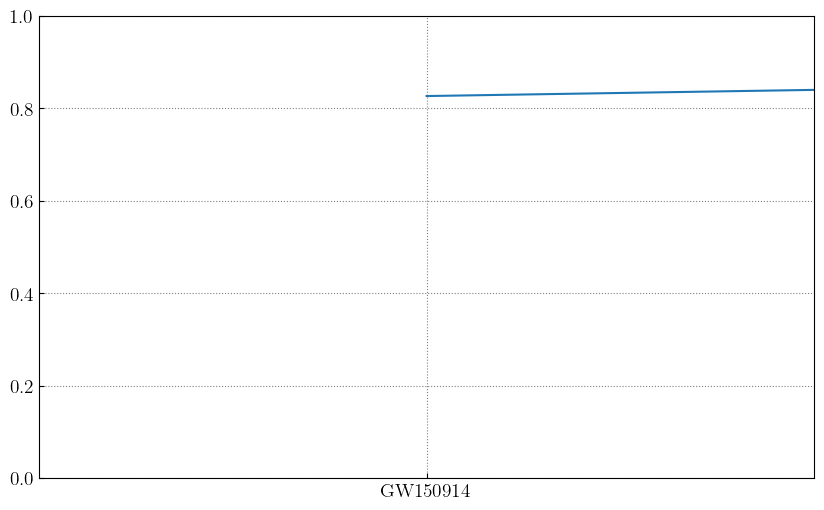

In [27]:
# Ensure all columns used in yerr and xerr are numeric
yerr_lower_bfs_orient = bfs_orient['bayes_factors_mean'] - bfs_orient['bayes_factors_mean_lowerCI']
yerr_upper_bfs_orient = bfs_orient['bayes_factors_mean_upperCI'] - bfs_orient['bayes_factors_mean']

xerr_lower_bfs = bfs['bayes_factors_mean'] - bfs['bayes_factors_mean_lowerCI']
xerr_upper_bfs = bfs['bayes_factors_mean_upperCI'] - bfs['bayes_factors_mean']

# Plotting the scatter plot with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(bfs['event'], bfs_orient['bayes_factors_mean'],
             xerr=[xerr_lower_bfs, xerr_upper_bfs],
             yerr=[yerr_lower_bfs_orient, yerr_upper_bfs_orient])

plt.xlabel('Event')
plt.ylabel('Bayes Factor (Orientation)')
plt.title('Bayes Factors with Error Bars (General vs Orientation)')
plt.legend()
plt.grid(True)
plt.show()

10000
eta_spin


Computing Spin Magnitude Model on the Grid:   0%|          | 0/1000 [00:00<?, ?it/s]

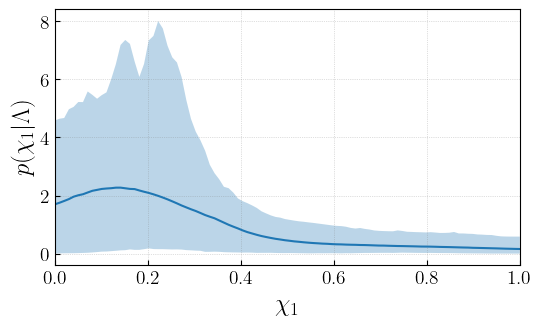

In [28]:
SpinMagintudePlot(makedict(posterior_samples), the_spin_magnitude_model_2D).spin_1_marginal_plot();

10000
eta_spin


Computing Spin Magnitude Model on the Grid:   0%|          | 0/1000 [00:00<?, ?it/s]

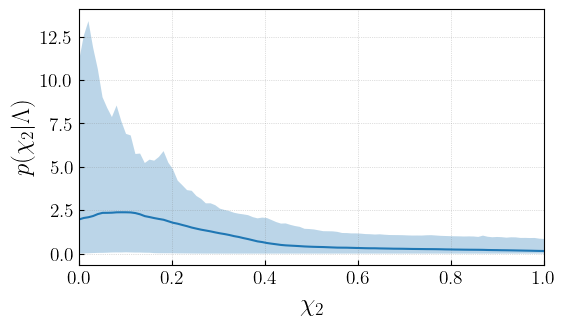

In [29]:
SpinMagintudePlot(makedict(posterior_samples), the_spin_magnitude_model_2D).spin_2_marginal_plot();

10000
eta_spin


Computing Spin Magnitude Model on the Grid:   0%|          | 0/10000 [00:00<?, ?it/s]

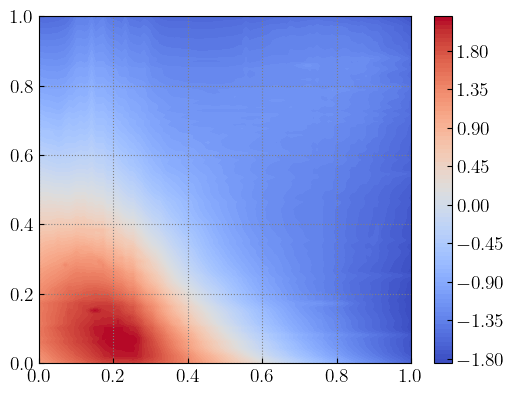

In [65]:
post_dict = makedict(posterior_samples);
smp = SpinMagintudePlot(post_dict, the_spin_magnitude_model_2D, n_samples=None)
smp.compute_if_not_computed()
#smp.result = smp.result * (1-post_dict['eta_spin'][:, None, None]);
#smp.spin_2D_plot_old_mean(levels=200, log_scale=True, func_to_use=jnp.mean);

plt.contourf(smp.spin_grid.data['chi_1'], smp.spin_grid.data['chi_2'], jnp.log(jnp.mean(smp.result, axis=0)), levels=100,
            cmap=matplotlib.cm.coolwarm)
plt.colorbar()
plt.show()

In [26]:
0post_dict = makedict(posterior_samples[(posterior_samples['sigma_chi_1_at_0'] > 0.00) & (posterior_samples['sigma_chi_2_at_0'] > 0.00)]);
smp = SpinMagintudePlot(post_dict, the_spin_magnitude_model_2D.models[0], n_samples=None)
smp.compute_if_not_computed()
smp.result = smp.result * post_dict['eta_spin'][:, None, None];
smp.spin_2D_plot_old_mean(levels=200, log_scale=False, func_to_use=jnp.mean);

SyntaxError: invalid decimal literal (580839093.py, line 1)

6520
mu_chi_1


Computing Spin Magnitude Model on the Grid:   0%|          | 0/6520 [00:00<?, ?it/s]

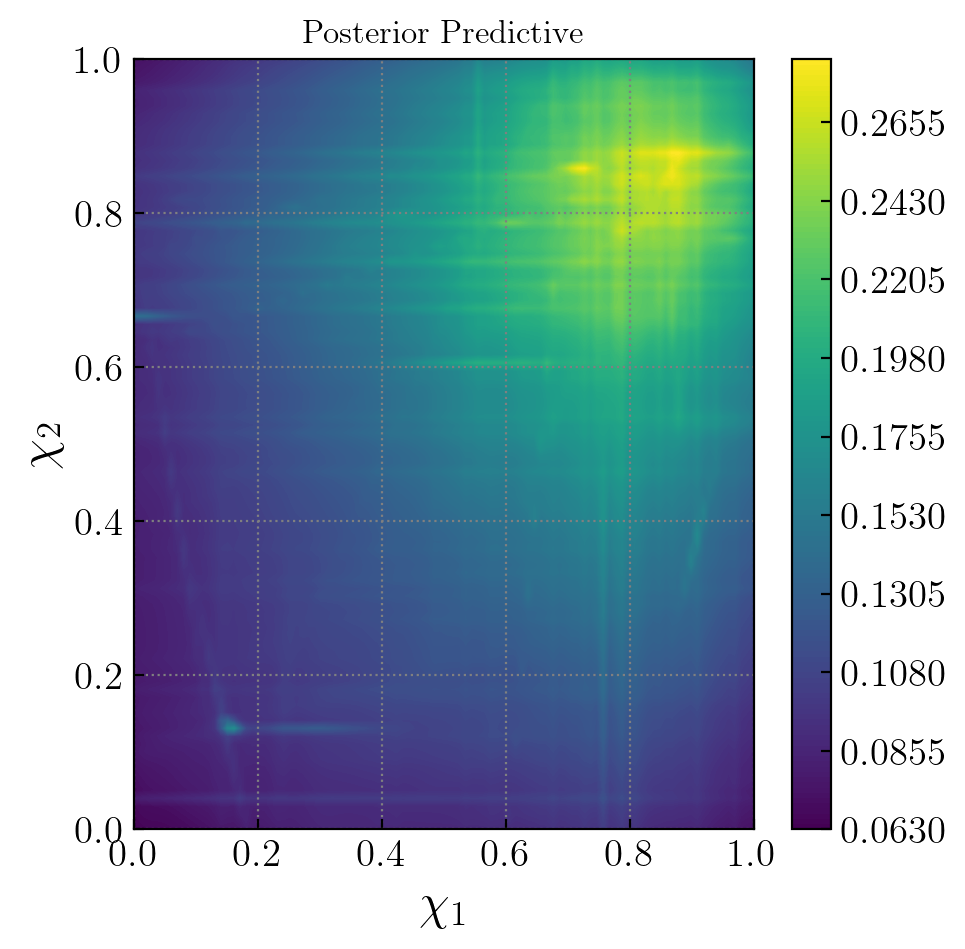

In [40]:
post_dict = makedict(posterior_samples[(posterior_samples['eta_spin'] > 0.75) & (posterior_samples['sigma_chi_1'] > 0.00) & (posterior_samples['sigma_chi_2'] > 0.0)]);
smp = SpinMagintudePlot(post_dict, the_spin_magnitude_model_2D.models[1], n_samples=None)
smp.compute_if_not_computed()
smp.result = smp.result * (1-post_dict['eta_spin'][:, None, None]);
smp.spin_2D_plot_old_mean(levels=200, log_scale=False, func_to_use=jnp.mean);

10000
mu_chi_1_at_0


Computing Spin Magnitude Model on the Grid:   0%|          | 0/10000 [00:00<?, ?it/s]

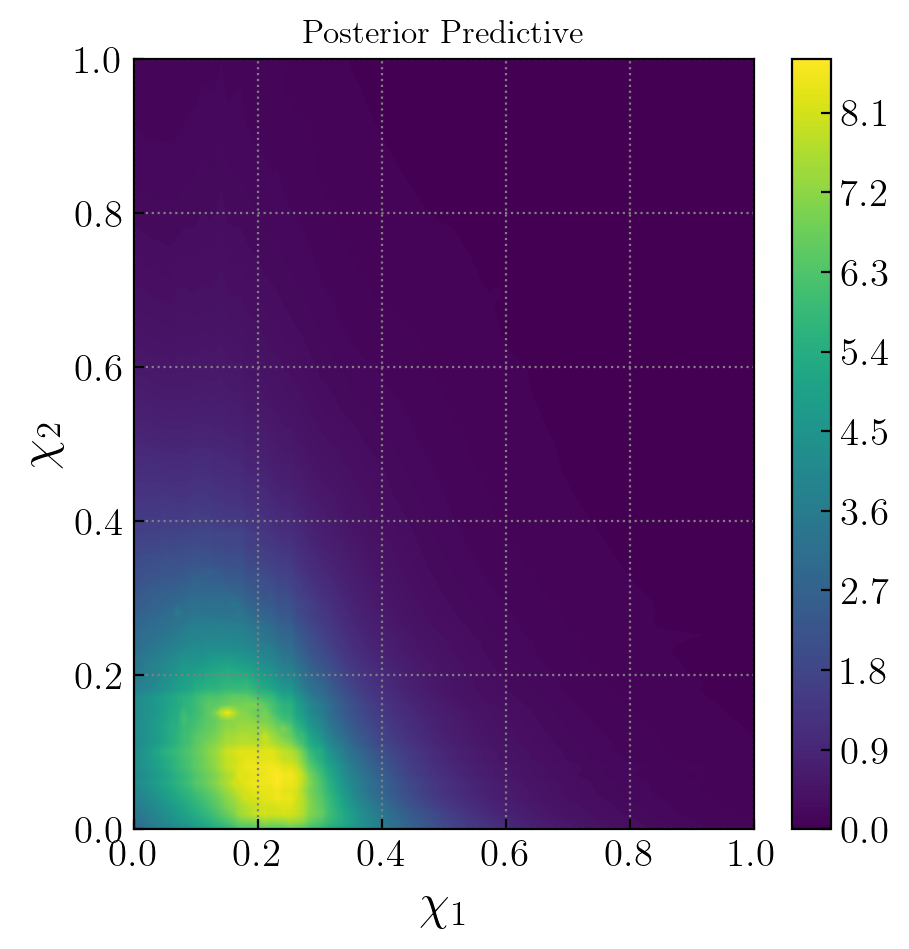

In [52]:
post_dict = makedict(posterior_samples);
smp = SpinMagintudePlot(post_dict, the_spin_magnitude_model_2D.models[0], n_samples=None)
smp.compute_if_not_computed()
smp.result = smp.result * (post_dict['eta_spin'][:, None, None]);
smp.spin_2D_plot_old_mean(levels=200, log_scale=False, func_to_use=jnp.mean);

10000
mu_chi_1


Computing Spin Magnitude Model on the Grid:   0%|          | 0/10000 [00:00<?, ?it/s]

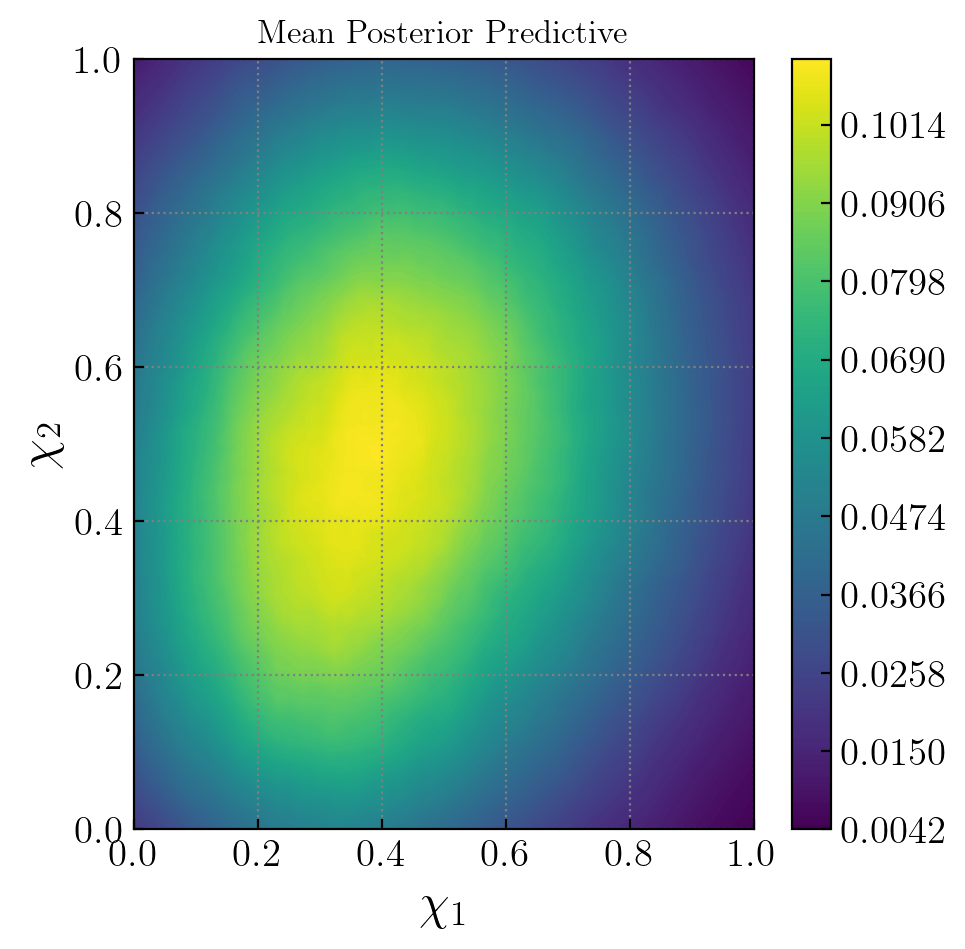

In [39]:
post_dict = makedict(posterior_samples_no_190517);
smp = SpinMagintudePlot(post_dict, the_spin_magnitude_model_2D.models[1], n_samples=None)
smp.compute_if_not_computed()
smp.result = smp.result * (1-post_dict['eta_spin'][:, None, None]);
smp.spin_2D_plot_old_mean(levels=200, log_scale=False, func_to_use=jnp.median);

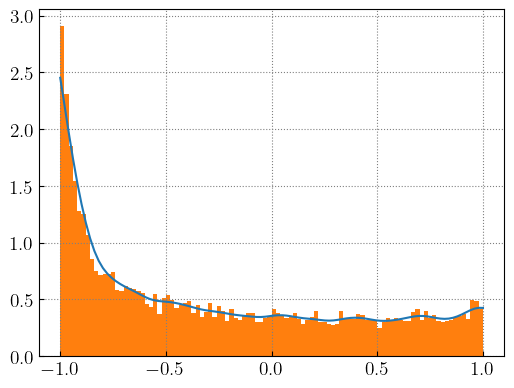

In [18]:
thekde = fit_kde(posterior_samples[['rho_chi_1']], [-1],[1], bandwidth_scale=0.5);
plt.plot(np.linspace(-1,1,100), [thekde.pdf(x) for x in np.linspace(-1,1,100)])
plt.hist(posterior_samples['rho_chi_1'], density=True, bins=100);
plt.show()

In [605]:
posterior_samples[posterior_samples['eta_spin'] > posterior_samples['eta_spin'].quantile(0.3)].mean()#[(posterior_samples['sigma_chi_1'] < 0.25) & (posterior_samples['sigma_chi_2'] < 0.25)].mean()

Unnamed: 0          5024.441857
alpha                  3.596046
beta                   1.081153
delta_m                4.965459
eta_spin               0.850470
lam                    0.041260
lamb                   3.390005
mmax                  85.797722
mmin                   5.014913
mpp                   33.545206
mu_chi_1               0.599761
mu_chi_1_at_0          0.157277
mu_chi_2               0.576992
mu_chi_2_at_0          0.130740
rho_chi_1             -0.269655
rho_chi_2              0.055262
sigma_chi_1            0.536146
sigma_chi_1_at_0       0.264574
sigma_chi_2            0.490962
sigma_chi_2_at_0       0.257871
sigma_spin             1.833870
sigpp                  4.165293
xi_spin                0.609164
rho_chi_1_true        -0.126442
rho_chi_2_true         0.035902
dtype: float64

In [23]:
0.5*10_000**(-1/5)

0.07924465962305567

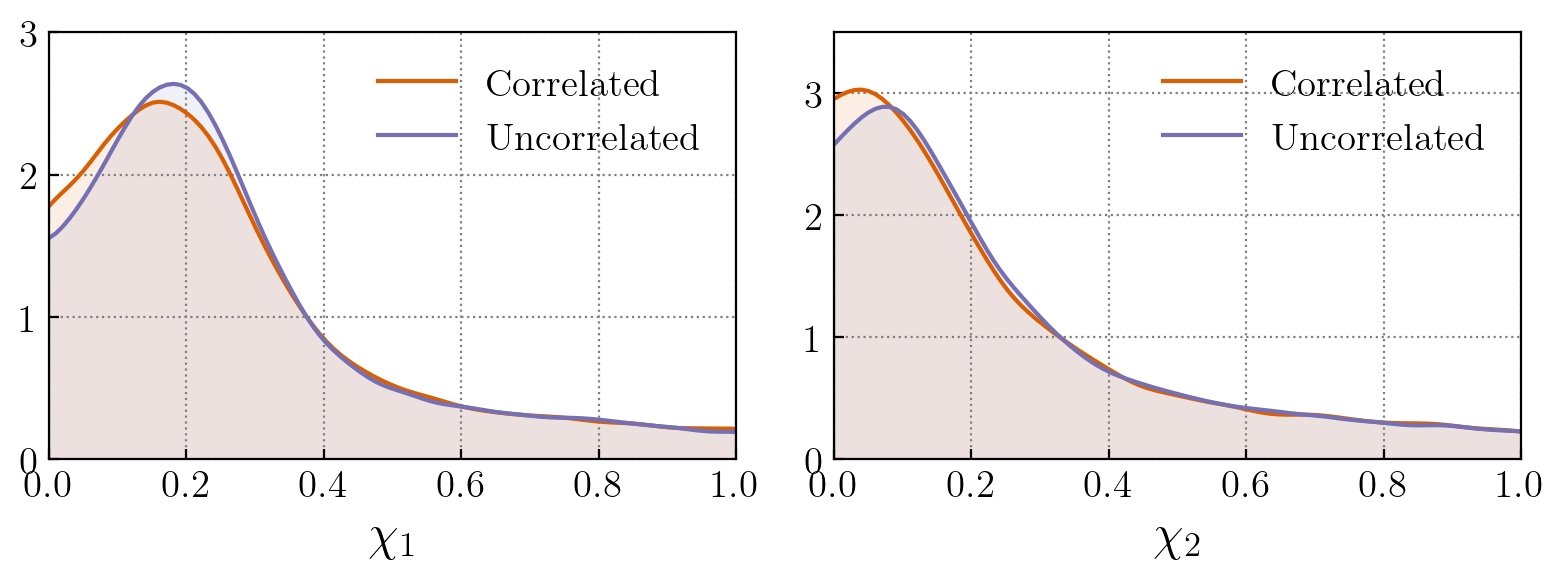

In [40]:
from truncnormkde import *
cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

oversample = 50_000 // len(posterior_samples[cond])
dfsamps = the_spin_magnitude_model_2D.sample(posterior_samples[cond], oversample=oversample)

cond = np.ones_like(posterior_samples['mu_chi_1'], dtype='bool')
#cond &= (posterior_samples['eta_spin'] > np.percentile(posterior_samples['eta_spin'], 10))

posterior_samples_two_uncorrelated = pd.read_csv("/Users/asadh/Documents/GitHub/SpinMagnitudePopulationAnalysis/data/hyper_posterior_samples/TwoComponent/Two-Component-Free-more-samples.csv");

the_spin_magnitude_model_2D_uncorr = FixedParameters(Mixture2D(
                                                TruncatedGaussian1DIndependentAnalytic(var_names=var_names,
                                                                            hyper_var_names=['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0'],
                                                                            a=0, b=1),
                                                TruncatedGaussian1DIndependentAnalytic(var_names=var_names,
                                                                            hyper_var_names=['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2'],
                                                                            a=0, b=1),
                                                'eta_spin'
                                            ), {})

oversample = 50_000 // len(posterior_samples_two_uncorrelated[cond])
dfsamps2 = the_spin_magnitude_model_2D_uncorr.sample(posterior_samples_two_uncorrelated[cond], oversample=oversample)

#fig = make_2D_comparison(dfsamps, dfsamps2, legend_location='upper left')

fit_chi_1_a = fit_kde(dfsamps[['chi_1']], [0], [1], bandwidth_scale=1);
fit_chi_2_a = fit_kde(dfsamps[['chi_2']], [0], [1], bandwidth_scale=1);
fit_chi_1_b = fit_kde(dfsamps2[['chi_1']], [0], [1], bandwidth_scale=1);
fit_chi_2_b = fit_kde(dfsamps2[['chi_2']], [0], [1], bandwidth_scale=1);

chis = np.linspace(0,1,100)
pdf_chi_1_a = fit_chi_1_a.pdf(chis.reshape(100,1))
pdf_chi_2_a = fit_chi_2_a.pdf(chis.reshape(100,1))
pdf_chi_1_b = fit_chi_1_b.pdf(chis.reshape(100,1))
pdf_chi_2_b = fit_chi_2_b.pdf(chis.reshape(100,1))


fig, axes = plt.subplots(figsize=(8,3),dpi=200, ncols=2)

axes[0].plot(chis, pdf_chi_1_a, label="Correlated", color=default_pallete[1])
axes[0].fill_between(chis, pdf_chi_1_a, alpha=0.1, color=default_pallete[1])
axes[1].plot(chis, pdf_chi_2_a, label="Correlated", color=default_pallete[1])
axes[1].fill_between(chis, pdf_chi_2_a, alpha=0.1, color=default_pallete[1])

axes[0].plot(chis, pdf_chi_1_b, label="Uncorrelated", color=default_pallete[2])
axes[0].fill_between(chis, pdf_chi_1_b, alpha=0.1, color=default_pallete[2])
axes[1].plot(chis, pdf_chi_2_b, label="Uncorrelated", color=default_pallete[2])
axes[1].fill_between(chis, pdf_chi_2_b, alpha=0.1, color=default_pallete[2])

axes[0].set_xlabel(r'$\chi_1$')
axes[1].set_xlabel(r'$\chi_2$')

axes[0].set_xlim(0,1);
axes[0].set_ylim(0,3);
axes[1].set_xlim(0,1);
axes[1].set_ylim(0,3.5);

plt.tight_layout()
axes[0].legend(loc='upper right')
axes[1].legend()


plt.show()

fig.savefig(f"{root_folder}/figures/two_component_only_marginals_chi12_correlated_vs_uncorrelated.pdf", bbox_inches='tight',dpi=200)

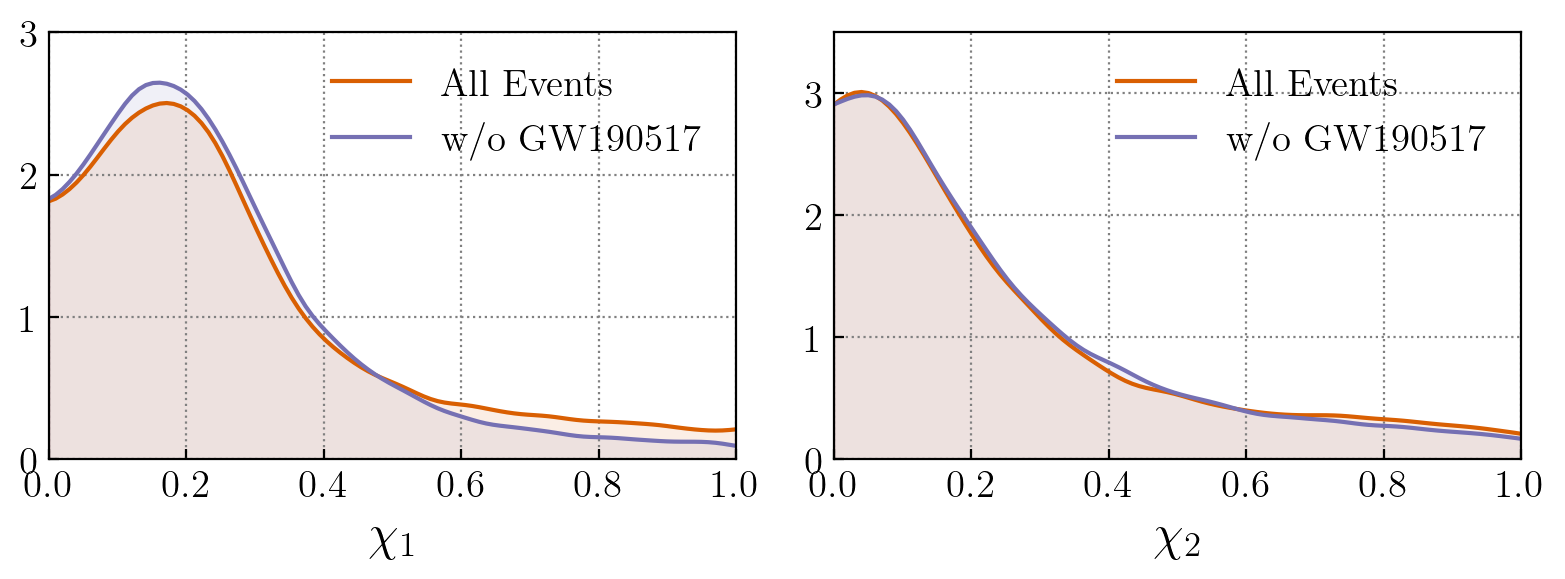